# Metropolis Algorithm

In [1]:
import random
import math
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from numba import njit

In [2]:
@njit
def initial_state(L, random_start=True):
    state = np.empty((L, L), dtype=np.int8)
    if random_start:
        # Random ±1 using threshold
        for i in range(L):
            for j in range(L):
                if np.random.random() < 0.5:
                    state[i, j] = 1
                else:
                    state[i, j] = -1
    else:
        # All spins up (+1)
        state[:] = 1
    return state

In [3]:
@njit
def system_energy(state, J, h):
    H = 0
    rows, cols = state.shape  
    for i in range(rows):
        for j in range(cols):
            s = state[i,j]
            # sum over nearest neighbors with periodic boundary conditions
            H -= J * s * (state[i, (j+1) % cols]) # right neighbor
            H -= J * s * (state[(i+1) % rows, j]) # bottom neighbor
            H -= h * s  # external magnetic field term
    return H

In [4]:
@njit
def local_energy_change(current_state, i, j, J, h):

    s = current_state[i, j]
    rows, cols = current_state.shape
    neighbor_sum = (
        current_state[i, (j + 1) % cols]
        + current_state[i, (j - 1) % cols]
        + current_state[(i + 1) % rows, j]
        + current_state[(i - 1) % rows, j]
    )
    delta_E = 2 * s * (J * neighbor_sum + h)
    return delta_E

In [5]:
@njit
def metropolis_step(current_state, J, h, beta):
    rows, cols = current_state.shape  

    # Random spin selection
    i = random.randint(0, rows-1)
    j = random.randint(0, cols-1)

    # Calculate local energy change
    delta_E = local_energy_change(current_state, i, j, J, h)

    # Decide whether to accept the new state
    if delta_E <= 0 or random.random() < math.exp(-beta * delta_E):
        current_state[i, j] *= -1  # accept flip
        return True, delta_E, (2 * current_state[i, j])
    else:
        return False, 0, 0  # reject flip

In [6]:
def run_metropolis(L, J, h, beta, n_steps):
    state = initial_state(L)
    
    energies = np.zeros(n_steps)
    magnetizations = np.zeros(n_steps)

    # Initial energy and magnetization
    current_energy = system_energy(state, J, h)
    energies[0] = current_energy
    current_magnetization = np.sum(state)
    magnetizations[0] = current_magnetization

    accepted = 0

    for step in range(1, n_steps):
        accepted_flag, delta_E, delta_M = metropolis_step(state, J, h, beta)
        if accepted_flag:
            accepted += 1
            current_energy += delta_E
            current_magnetization += delta_M

        energies[step] = current_energy
        magnetizations[step] = current_magnetization

    acceptance_rate = accepted / n_steps
    return energies, magnetizations, acceptance_rate, state

Plotting helpers

In [7]:
def plot_state(state):
    plt.imshow(state, cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
    plt.show()

In [ ]:
def plot_energies_and_magnetizations(energies, magnetizations):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(energies, label='Energy') 
    plt.xlabel('Step')
    plt.ylabel('Energy')
    plt.title('Energy vs. Steps')

    plt.subplot(1, 2, 2)
    plt.plot(magnetizations, label='Magnetization', color='orange')
    plt.xlabel('Step')
    plt.ylabel('Magnetization')
    plt.title('Magnetization vs. Steps')

    plt.tight_layout()
    plt.show()

# Simulation

In [9]:
run = "Metropolis_Temp_Scan_h0.0"
base_dir = f"data/{run}"

os.makedirs(base_dir, exist_ok=True)

Test

Acceptance rate: 0.4731


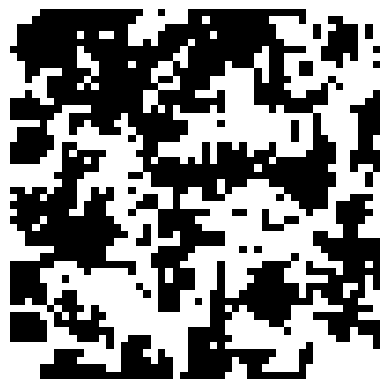

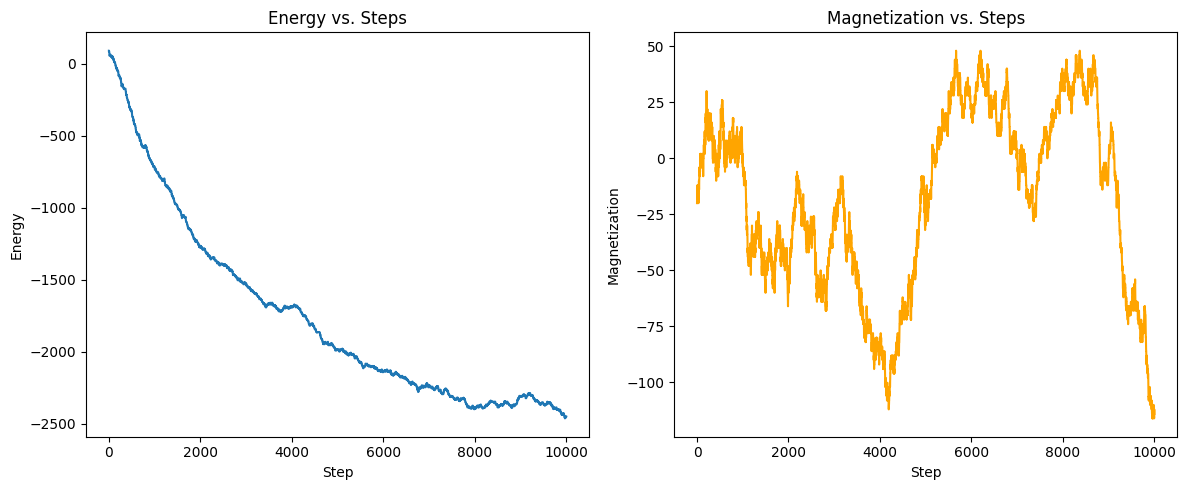

In [10]:
J = 1.0        # Interaction strength
L = 50        # Lattice size (100x100 spins)
n_steps = 10000  # Number of Metropolis steps
h = 0.0 # External magnetic field
beta = 0.4 # Inverse temperature

energies, magnetizations, acc_rate, final_state = run_metropolis(L, J, h, beta, n_steps)
print(f"Acceptance rate: {acc_rate:.4f}")
plot_state(final_state)
plot_energies_and_magnetizations(energies, magnetizations)

Main

In [11]:
# Parameters
J = 1.0        # Interaction strength
L = 100        # Lattice size (100x100 spins)
n_steps = 10_000_000  # Number of Metropolis steps per beta
h = 0.0        # External field strength

# Save parameter info
with open(f"data/{run}/parameters.txt", "w") as f:
    f.write(f"Run: {run}\n")
    f.write(f"Lattice size: {L}x{L}\n")
    f.write(f"Interaction strength J: {J}\n")
    f.write(f"External field h: {h}\n")
    f.write(f"Number of steps: {n_steps}\n")
    f.write(f"Output files: data/{run}/mag_eng_beta_*.npz\n")
    f.write(f"Data: energies, magnetizations\n")

In [12]:
# Beta list
beta_ls = [
    0.1, 0.2, 0.3, 0.4, 0.41, 0.42, 0.43, 0.44, 0.4407, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5, 0.6
]

with open(f"data/{run}/beta_list.txt", "w") as f:
    for beta in beta_ls:
        f.write(f"{beta}\n")

  0%|          | 0/16 [00:00<?, ?it/s]

Running simulation for beta = 0.1
Acceptance rate: 0.8490


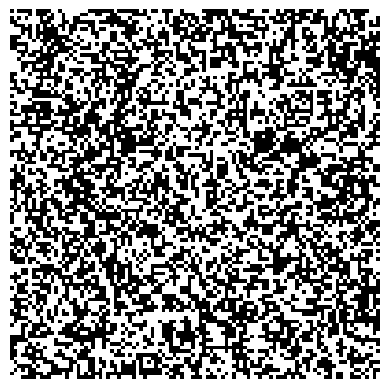

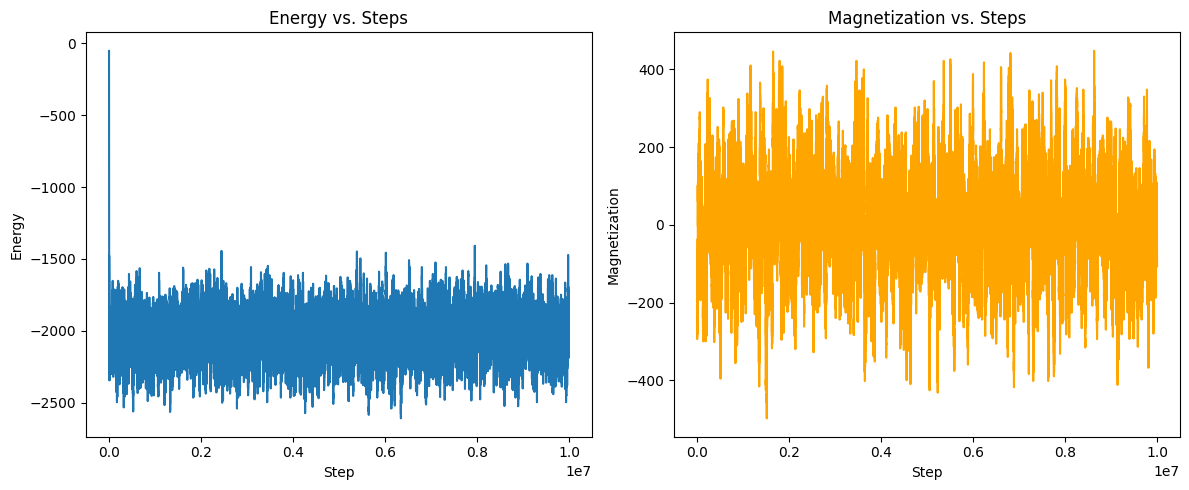

  6%|▋         | 1/16 [00:19<04:59, 19.99s/it]

Running simulation for beta = 0.2
Acceptance rate: 0.6923


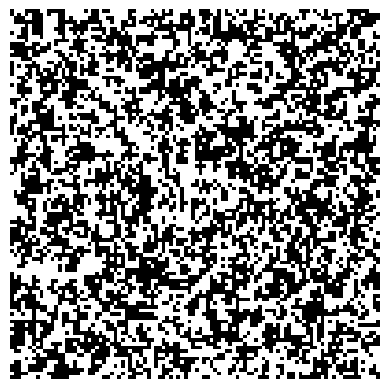

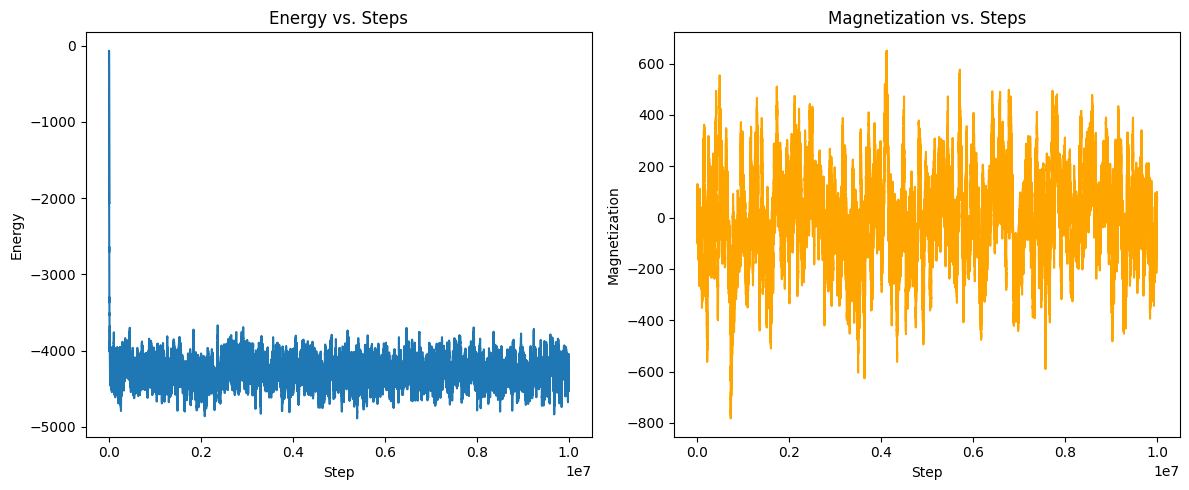

 12%|█▎        | 2/16 [01:16<09:39, 41.40s/it]

Running simulation for beta = 0.3
Acceptance rate: 0.5227


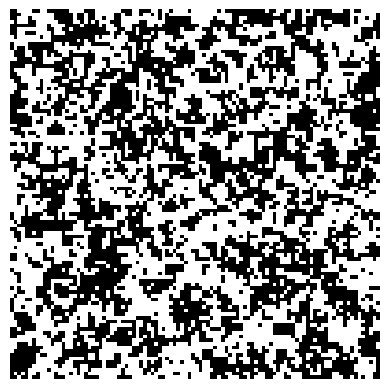

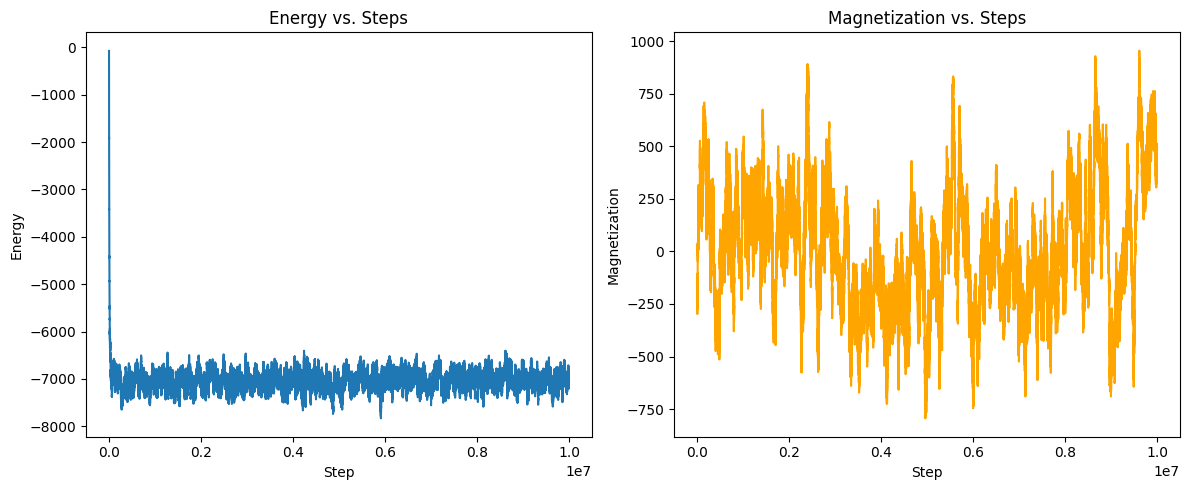

 19%|█▉        | 3/16 [02:20<11:11, 51.64s/it]

Running simulation for beta = 0.4
Acceptance rate: 0.3245


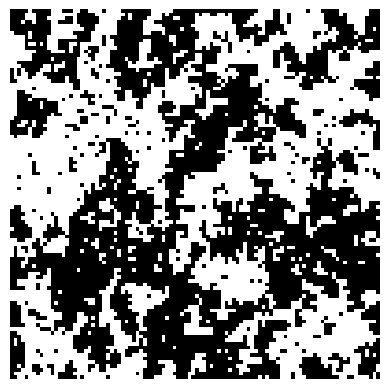

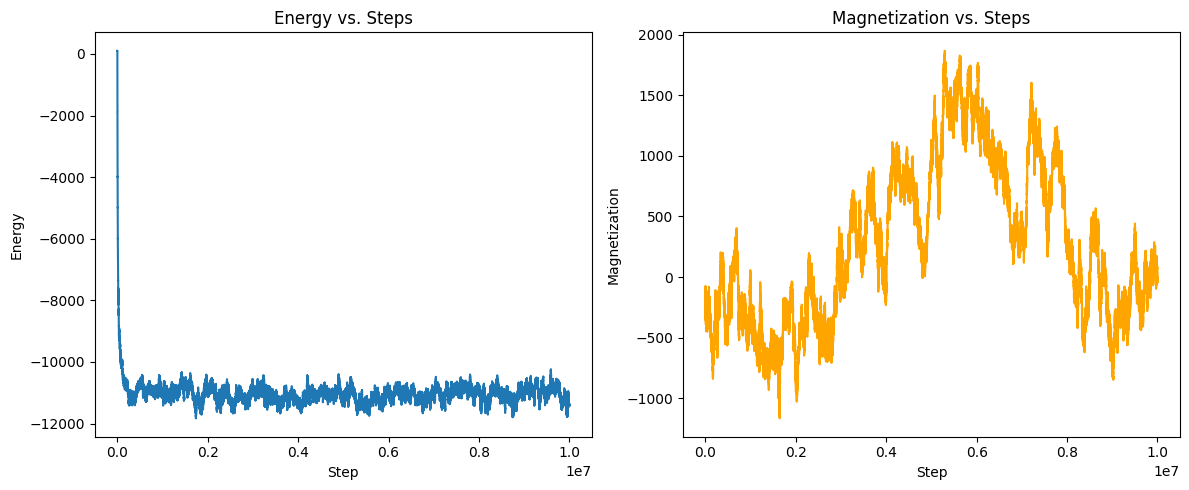

 25%|██▌       | 4/16 [02:55<09:04, 45.38s/it]

Running simulation for beta = 0.41
Acceptance rate: 0.2998


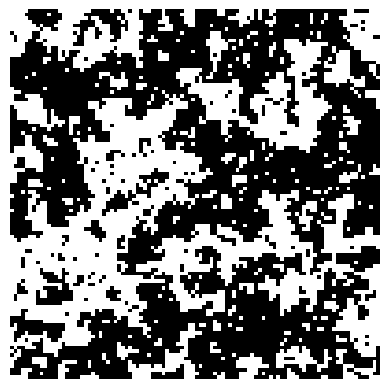

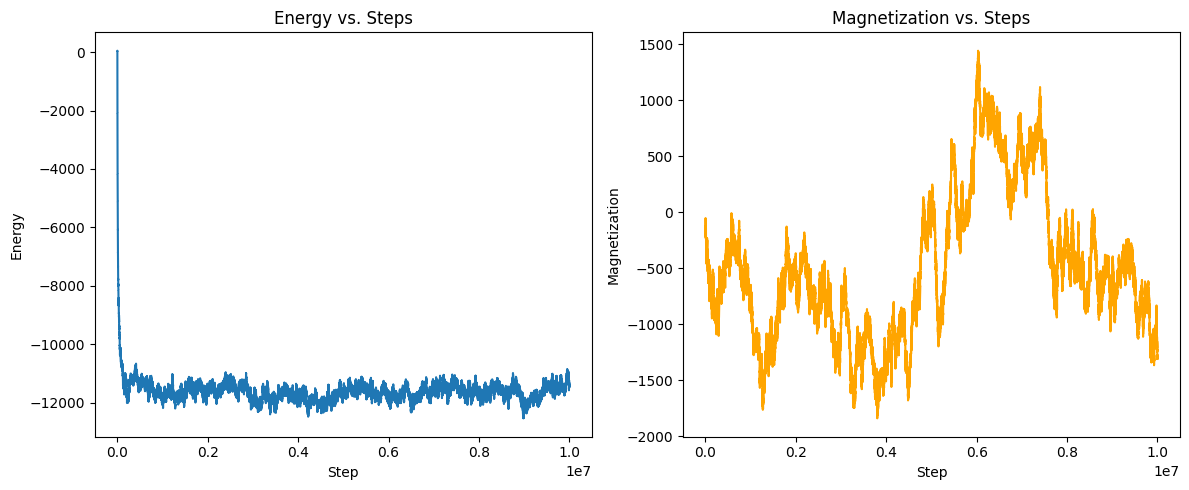

 31%|███▏      | 5/16 [03:44<08:30, 46.45s/it]

Running simulation for beta = 0.42
Acceptance rate: 0.2745


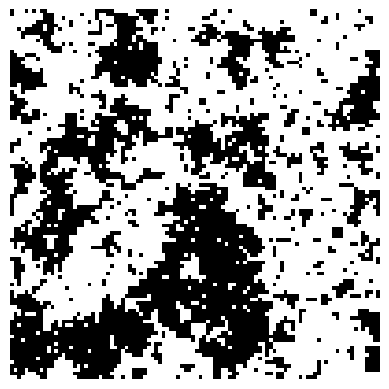

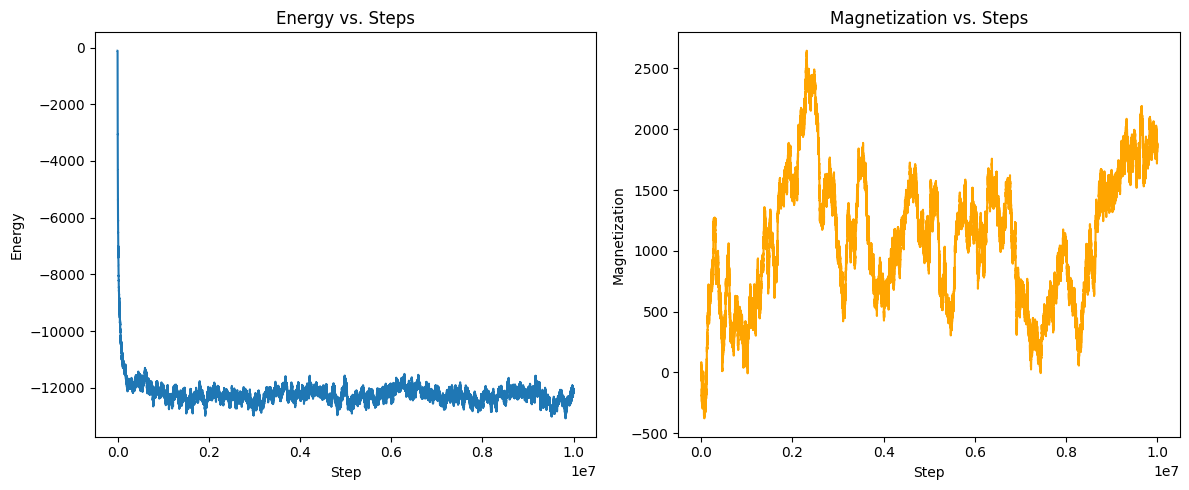

 38%|███▊      | 6/16 [04:32<07:49, 46.96s/it]

Running simulation for beta = 0.43
Acceptance rate: 0.2504


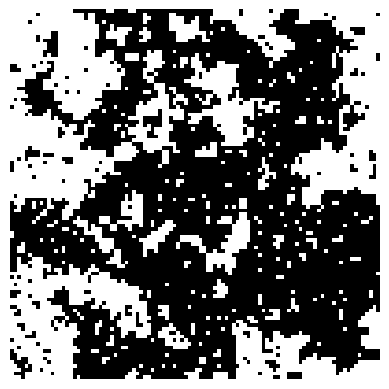

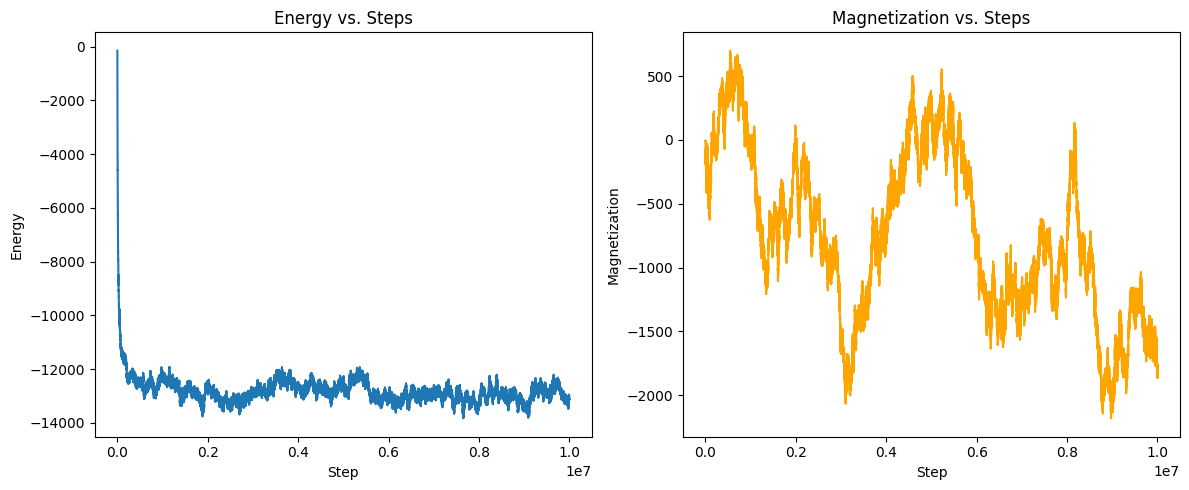

 44%|████▍     | 7/16 [05:26<07:22, 49.18s/it]

Running simulation for beta = 0.44
Acceptance rate: 0.2237


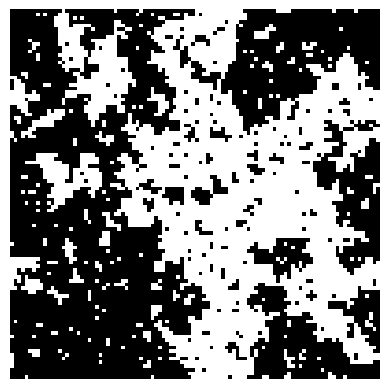

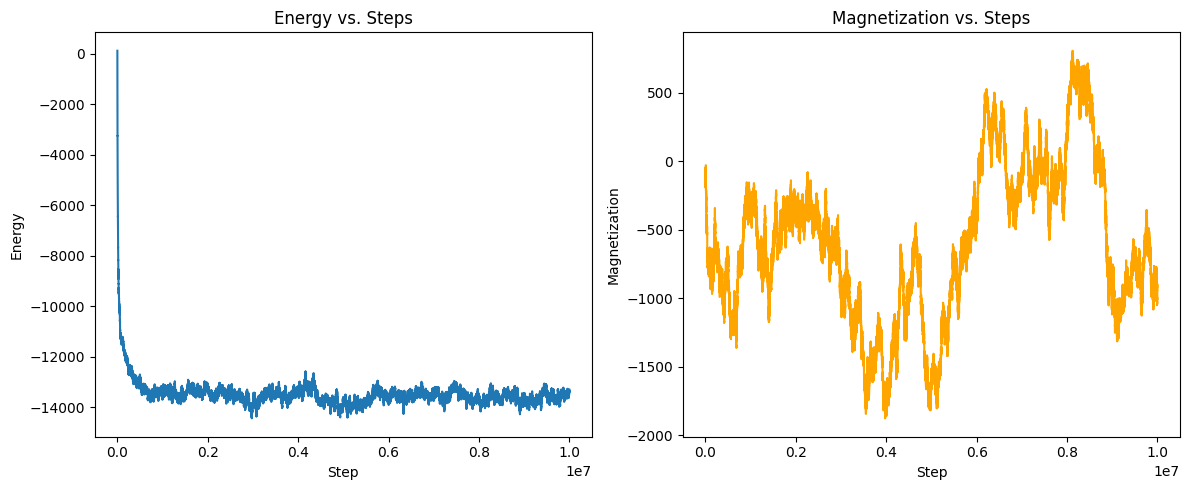

 50%|█████     | 8/16 [06:12<06:27, 48.39s/it]

Running simulation for beta = 0.4407
Acceptance rate: 0.2132


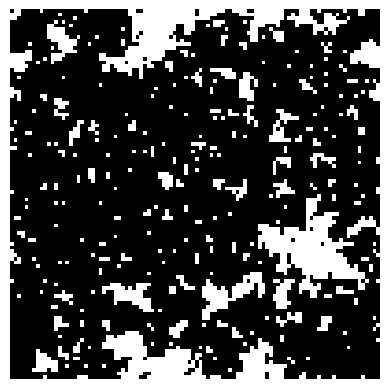

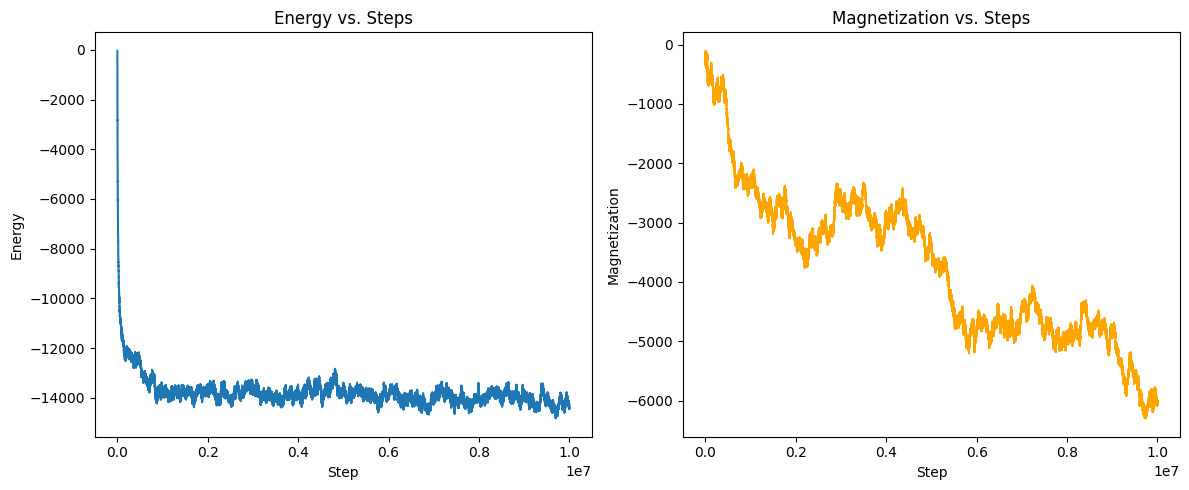

 56%|█████▋    | 9/16 [07:09<05:56, 50.95s/it]

Running simulation for beta = 0.45
Acceptance rate: 0.2002


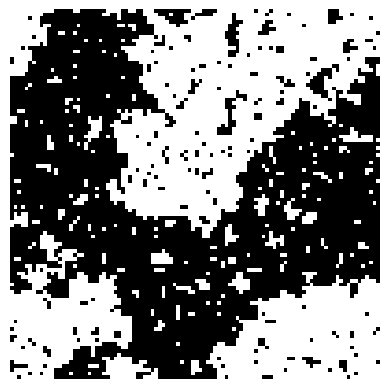

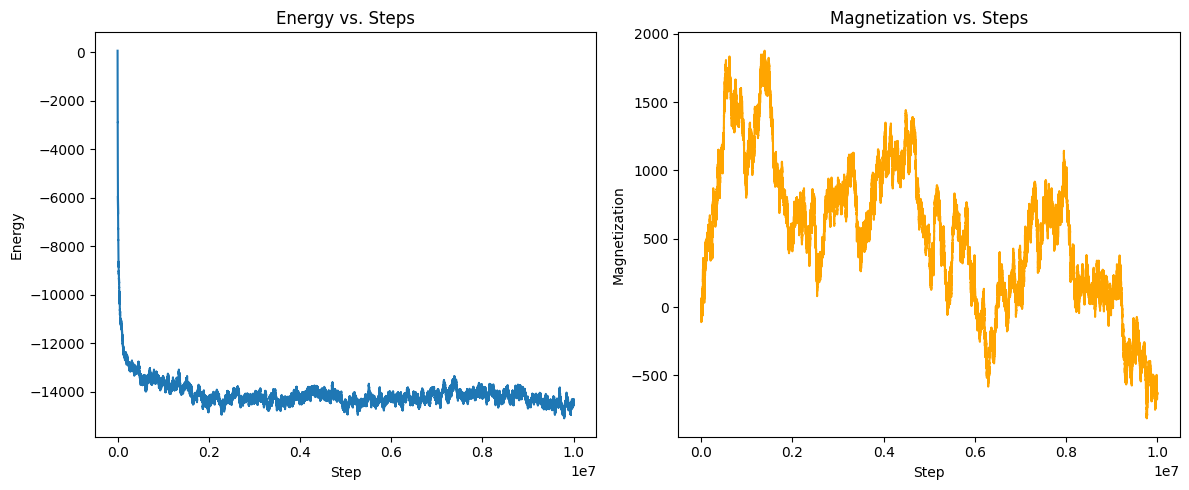

 62%|██████▎   | 10/16 [08:08<05:20, 53.42s/it]

Running simulation for beta = 0.46
Acceptance rate: 0.1709


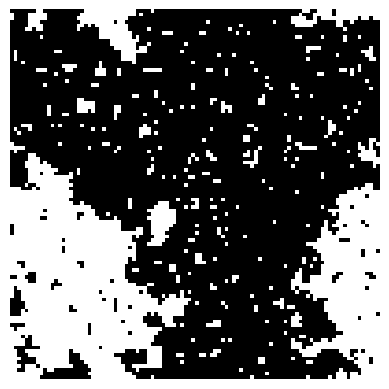

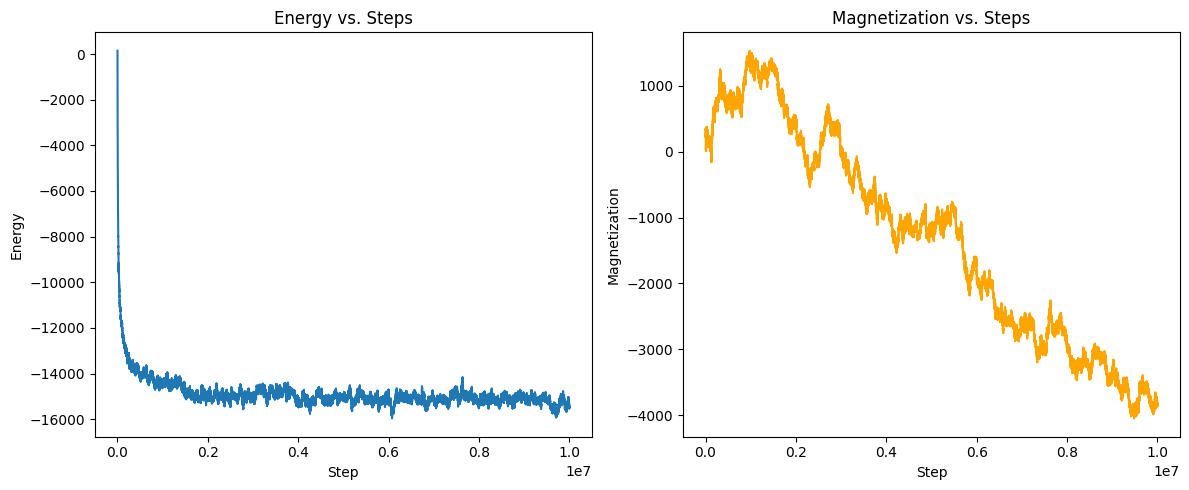

 69%|██████▉   | 11/16 [08:57<04:20, 52.18s/it]

Running simulation for beta = 0.47
Acceptance rate: 0.1537


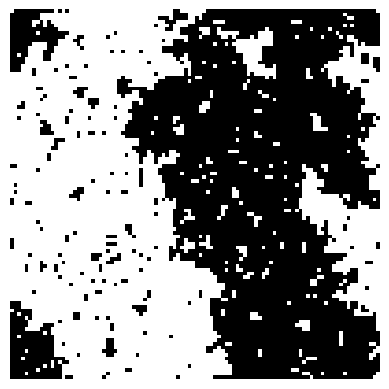

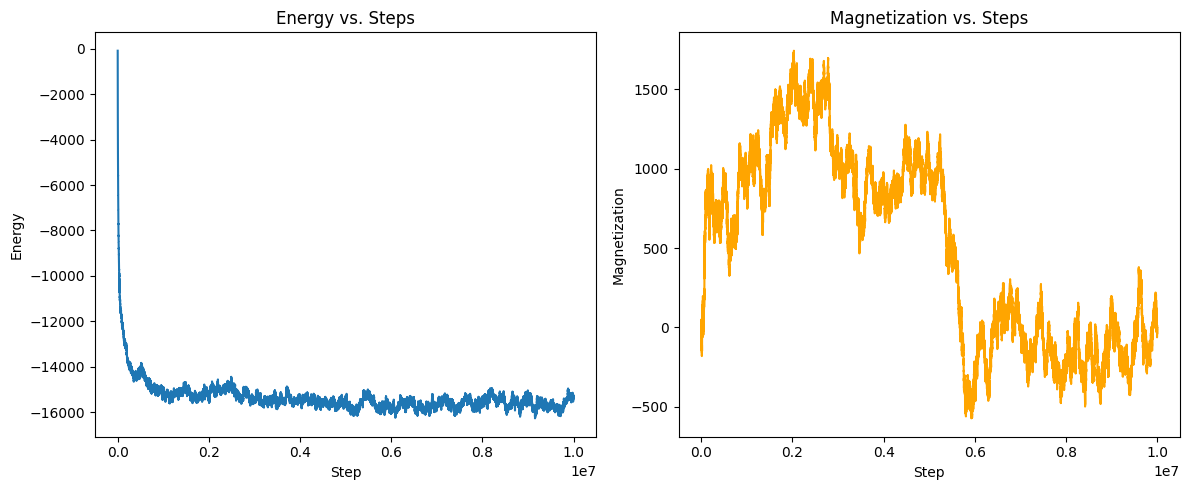

 75%|███████▌  | 12/16 [09:42<03:20, 50.04s/it]

Running simulation for beta = 0.48
Acceptance rate: 0.1486


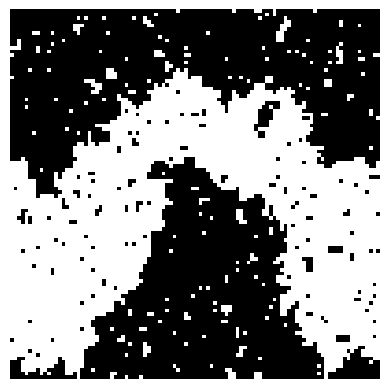

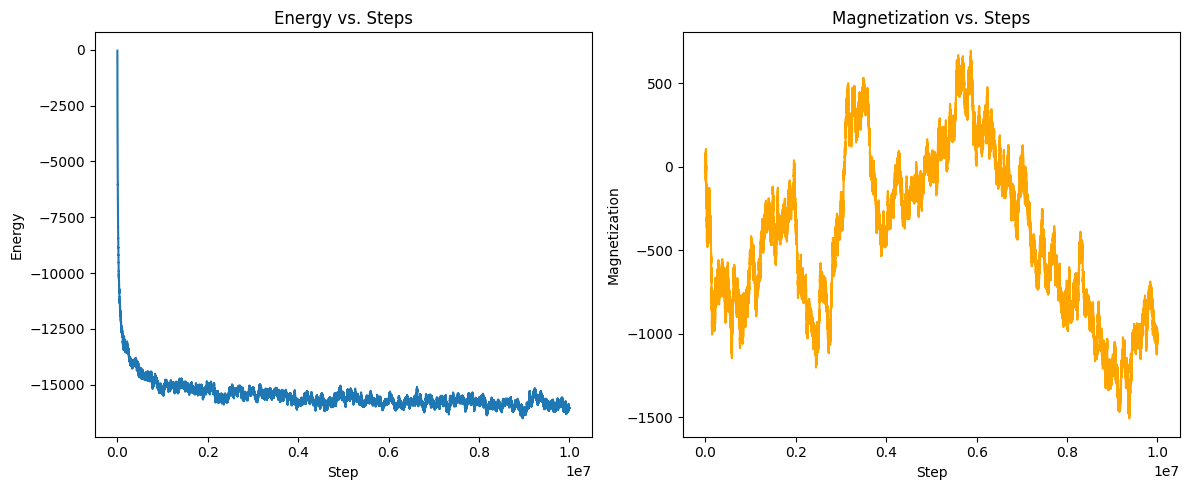

 81%|████████▏ | 13/16 [10:30<02:27, 49.21s/it]

Running simulation for beta = 0.49
Acceptance rate: 0.1284


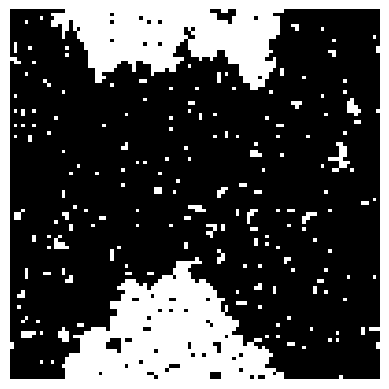

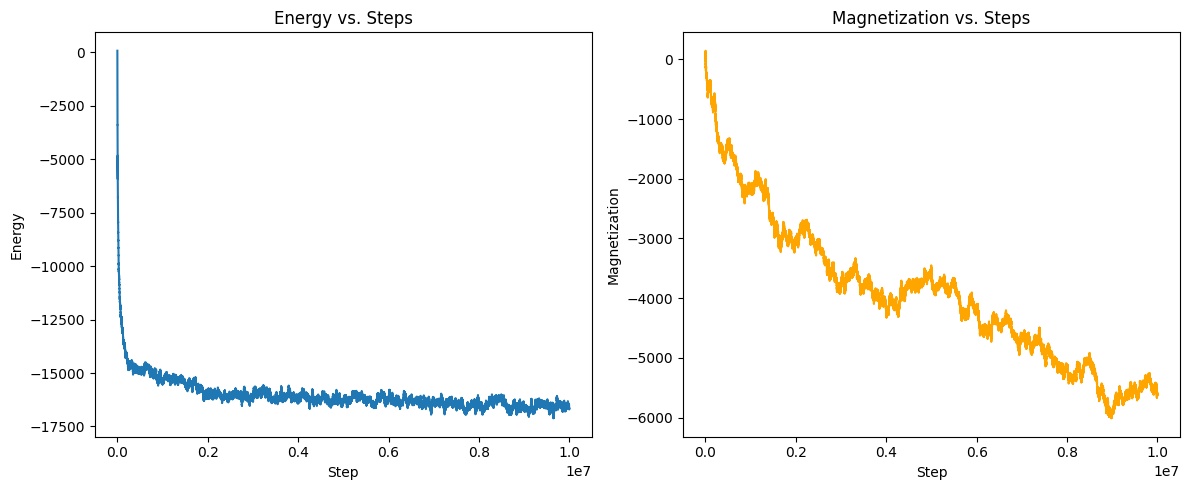

 88%|████████▊ | 14/16 [11:15<01:36, 48.12s/it]

Running simulation for beta = 0.5
Acceptance rate: 0.1138


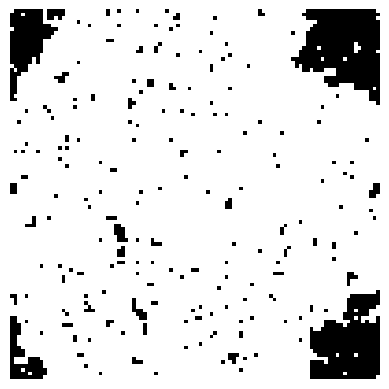

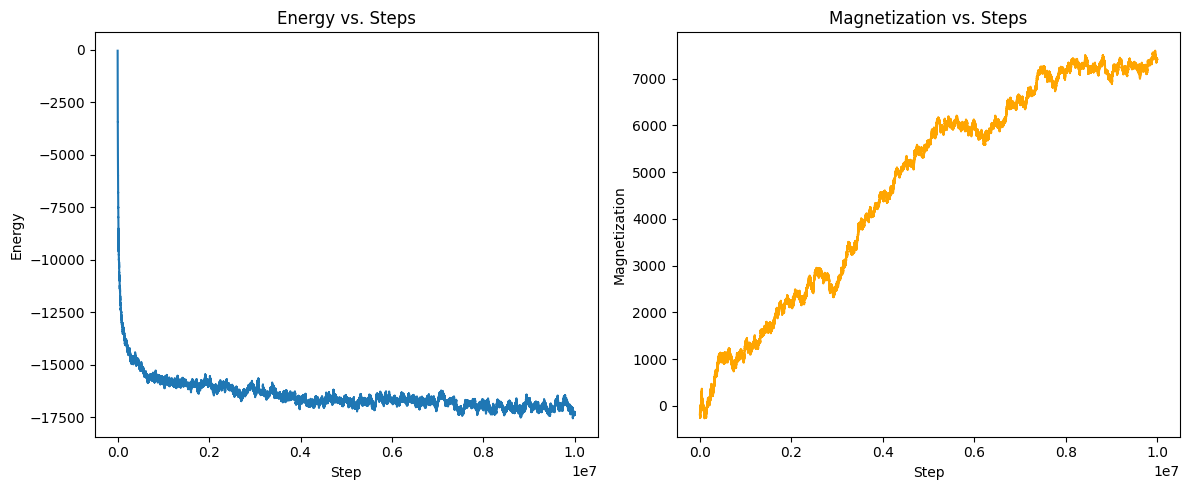

 94%|█████████▍| 15/16 [11:56<00:45, 45.97s/it]

Running simulation for beta = 0.6
Acceptance rate: 0.0601


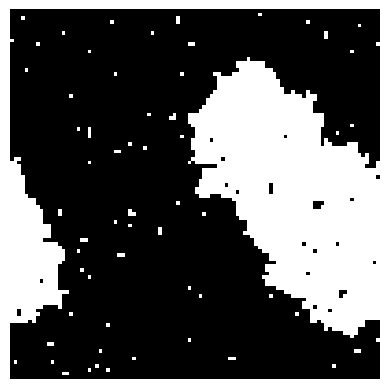

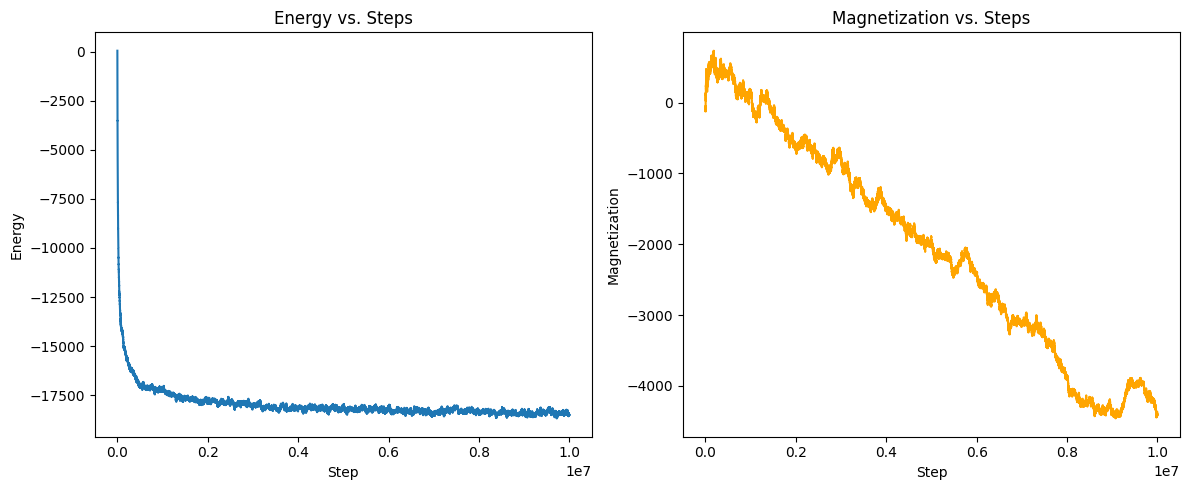

100%|██████████| 16/16 [12:16<00:00, 46.02s/it]


In [13]:
run1_dir = f"{base_dir}/first_states"
os.makedirs(run1_dir, exist_ok=True)

run1_checkpoint_dir = f"{run1_dir}/checkpoint_states"
os.makedirs(run1_checkpoint_dir, exist_ok=True)

run1_results_dir = f"{run1_dir}/results"
os.makedirs(run1_results_dir, exist_ok=True)

# Main simulation loop
for beta in tqdm(beta_ls):
    print(f"Running simulation for beta = {beta}")
    energies, magnetizations, acc_rate, final_state = run_metropolis(L, J, h, beta, n_steps)
    
    # Save results
    np.savez_compressed(f"{run1_results_dir}/mag_eng_beta_{beta:.4f}.npz", 
                        energies=energies, 
                        magnetizations=magnetizations,
                        acceptance_rate=acc_rate)
    
    np.save(
        f"{run1_checkpoint_dir}/state_beta_{beta:.4f}.npy",
        final_state.astype(np.int8)
    )
    
    print(f"Acceptance rate: {acc_rate:.4f}")
    plot_state(final_state)
    plot_energies_and_magnetizations(energies, magnetizations)

Equilibration not reached after $10^6$ steps. Continue from last saved state.

In [14]:
def continue_metropolis(state, J, h, beta, n_steps):
    """Continue simulation from an existing lattice state."""
    L = state.shape[0]
    energies = np.zeros(n_steps)
    magnetizations = np.zeros(n_steps)

    current_energy = system_energy(state, J, h)
    current_magnetization = np.sum(state)
    accepted = 0

    for step in range(n_steps):
        accepted_flag, delta_E, delta_M = metropolis_step(state, J, h, beta)
        if accepted_flag:
            accepted += 1
            current_energy += delta_E
            current_magnetization += delta_M
        energies[step] = current_energy
        magnetizations[step] = current_magnetization

    acceptance_rate = accepted / n_steps
    return energies, magnetizations, acceptance_rate, state

β sweep:   0%|          | 0/16 [00:00<?, ?it/s]

Loading checkpoint for β=0.1000
Acceptance rate: 0.8491


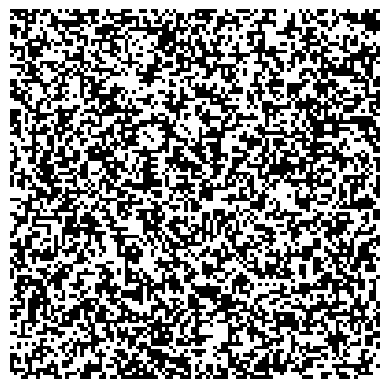

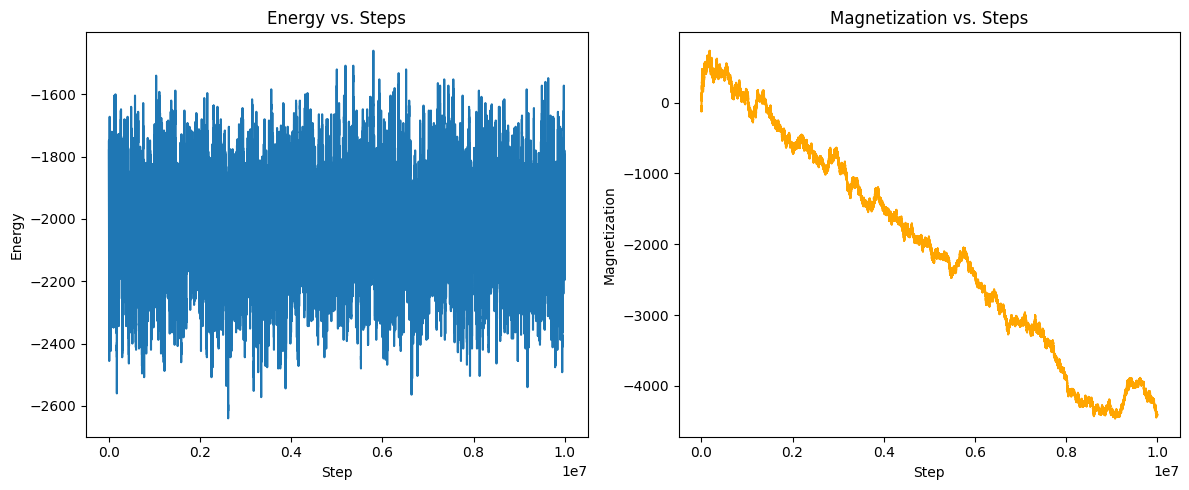

β sweep:   6%|▋         | 1/16 [00:46<11:43, 46.92s/it]

Loading checkpoint for β=0.2000
Acceptance rate: 0.6921


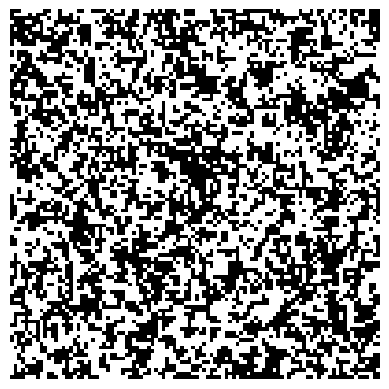

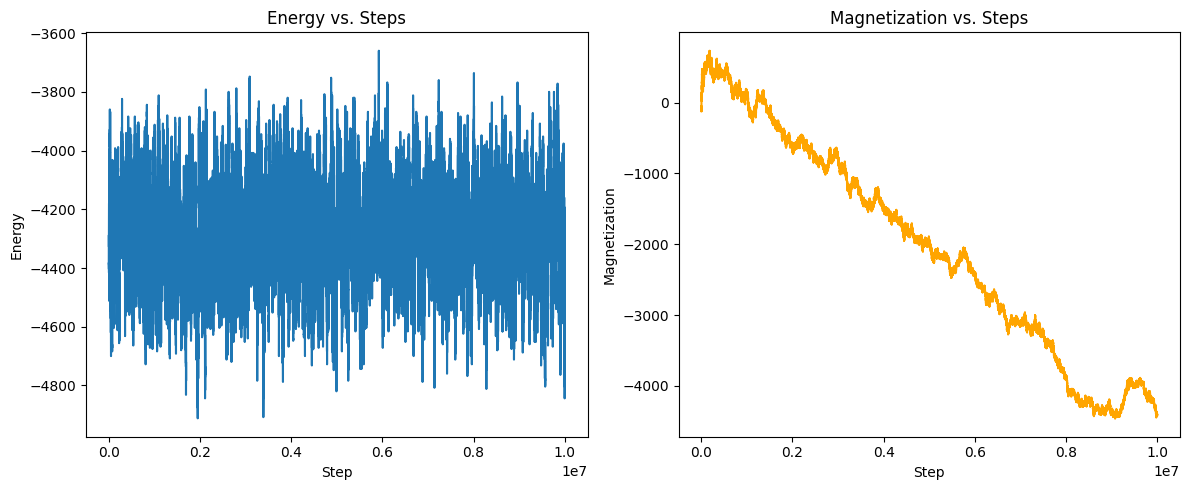

β sweep:  12%|█▎        | 2/16 [01:40<11:54, 51.03s/it]

Loading checkpoint for β=0.3000
Acceptance rate: 0.5219


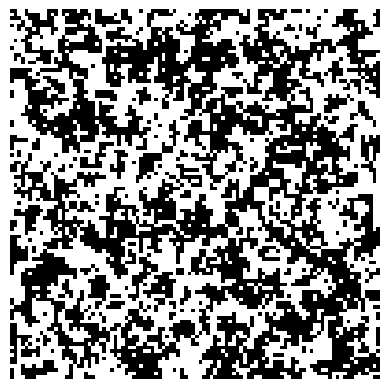

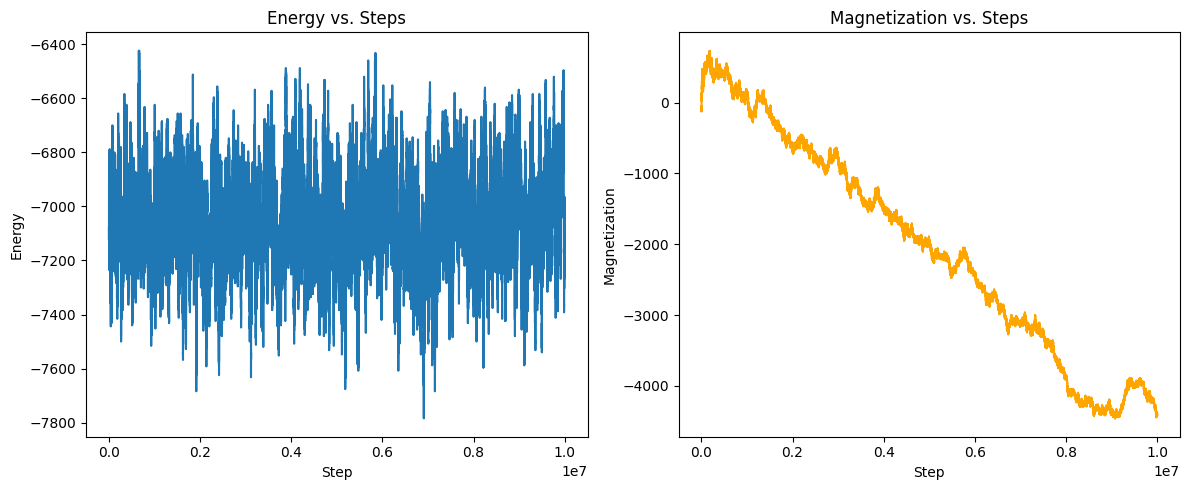

β sweep:  19%|█▉        | 3/16 [02:34<11:19, 52.23s/it]

Loading checkpoint for β=0.4000
Acceptance rate: 0.3231


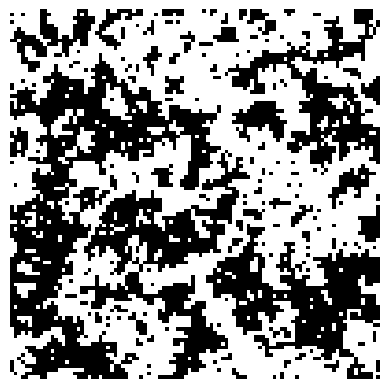

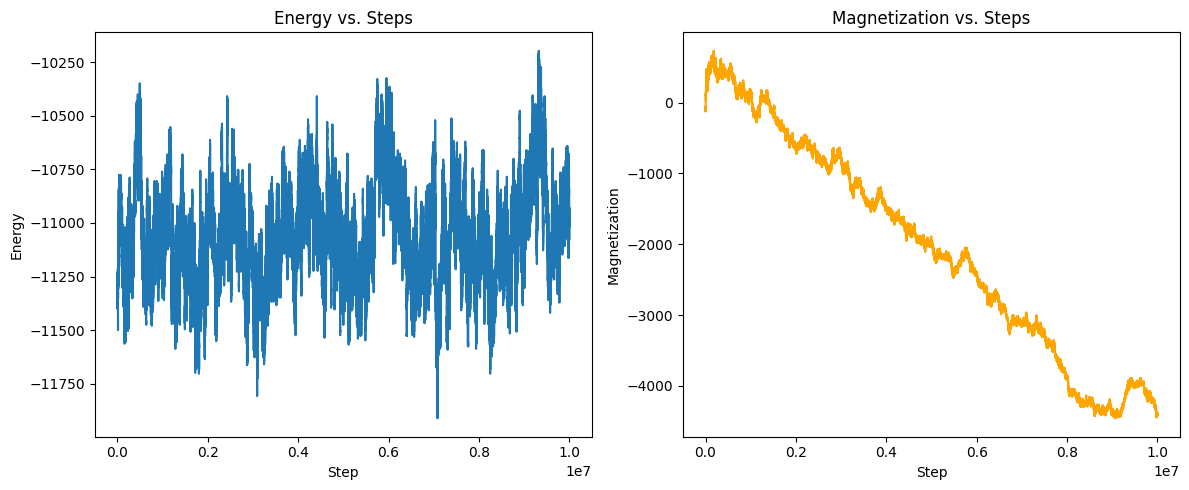

β sweep:  25%|██▌       | 4/16 [03:10<09:11, 46.00s/it]

Loading checkpoint for β=0.4100
Acceptance rate: 0.3011


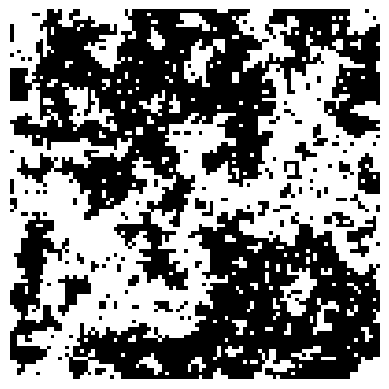

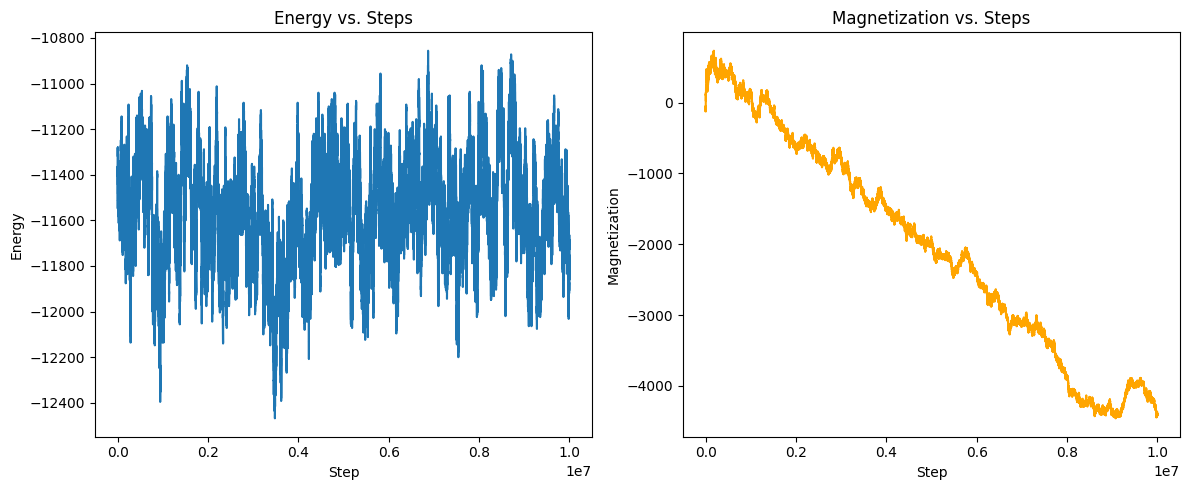

β sweep:  31%|███▏      | 5/16 [03:43<07:31, 41.08s/it]

Loading checkpoint for β=0.4200
Acceptance rate: 0.2743


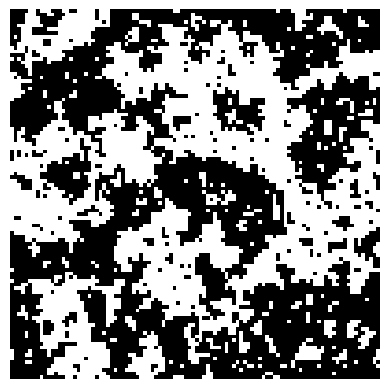

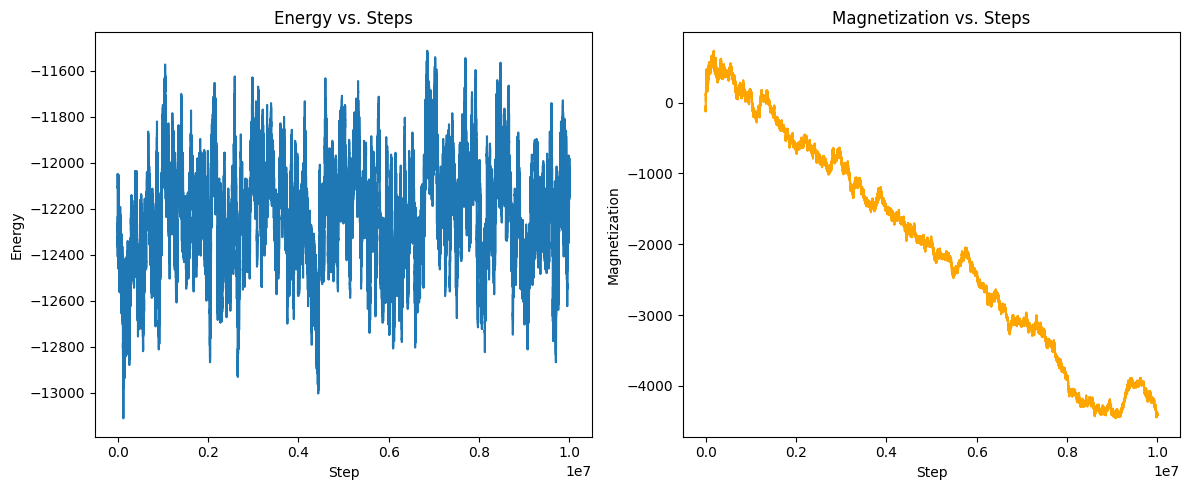

β sweep:  38%|███▊      | 6/16 [04:46<08:07, 48.73s/it]

Loading checkpoint for β=0.4300
Acceptance rate: 0.2451


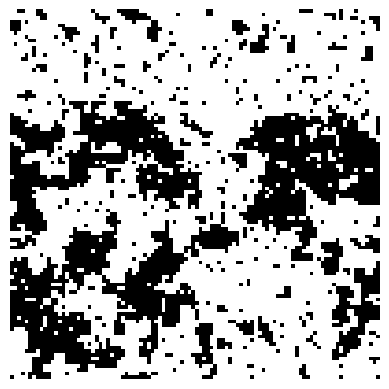

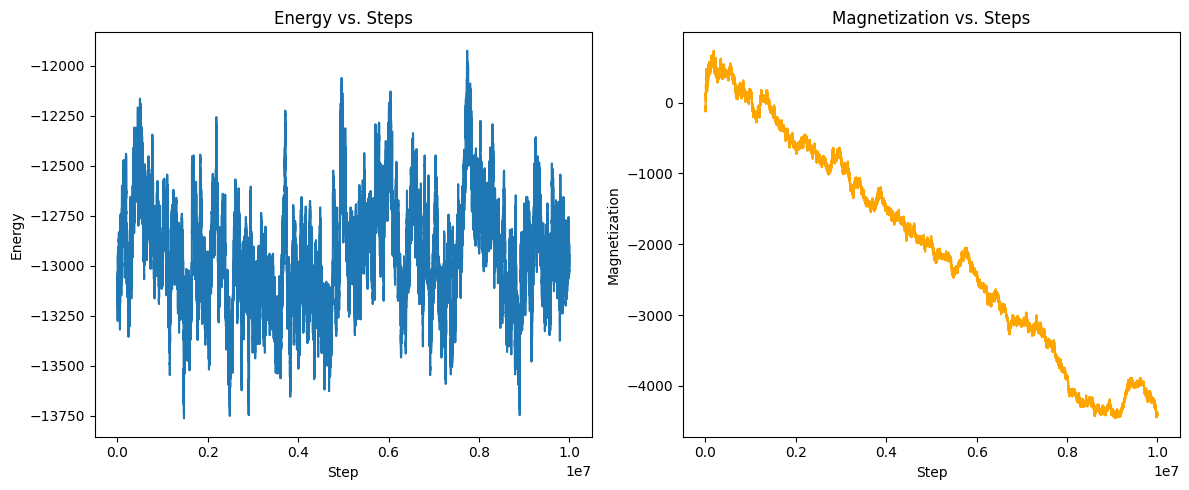

β sweep:  44%|████▍     | 7/16 [05:43<07:40, 51.16s/it]

Loading checkpoint for β=0.4400
Acceptance rate: 0.2161


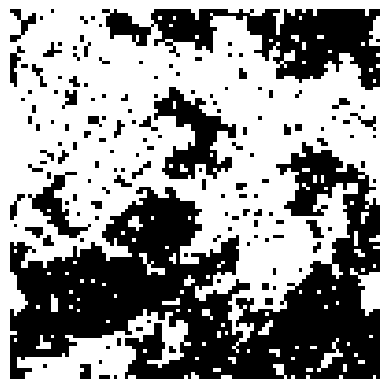

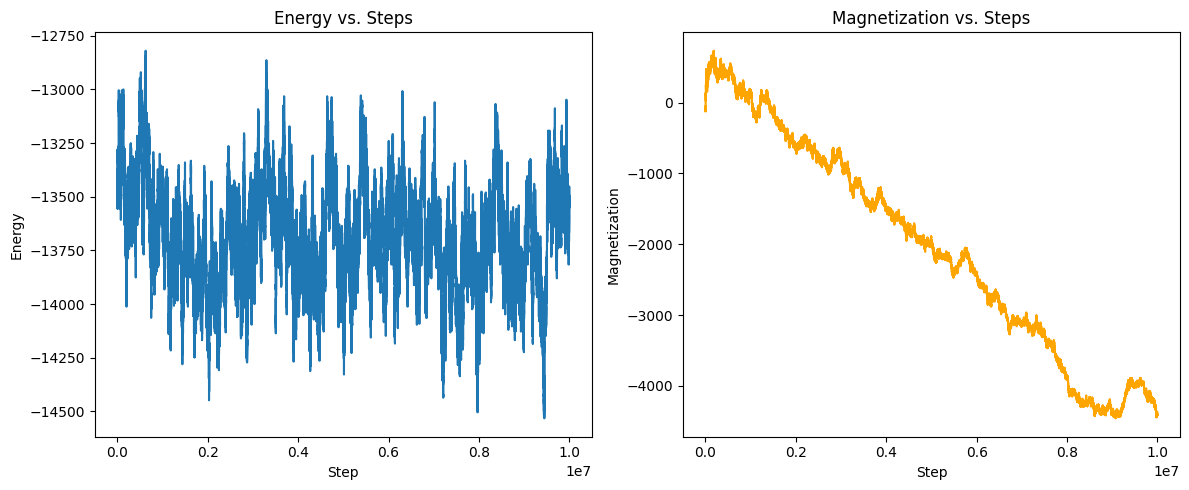

β sweep:  50%|█████     | 8/16 [06:36<06:55, 51.89s/it]

Loading checkpoint for β=0.4407
Acceptance rate: 0.2059


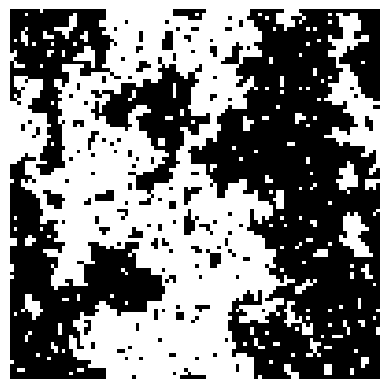

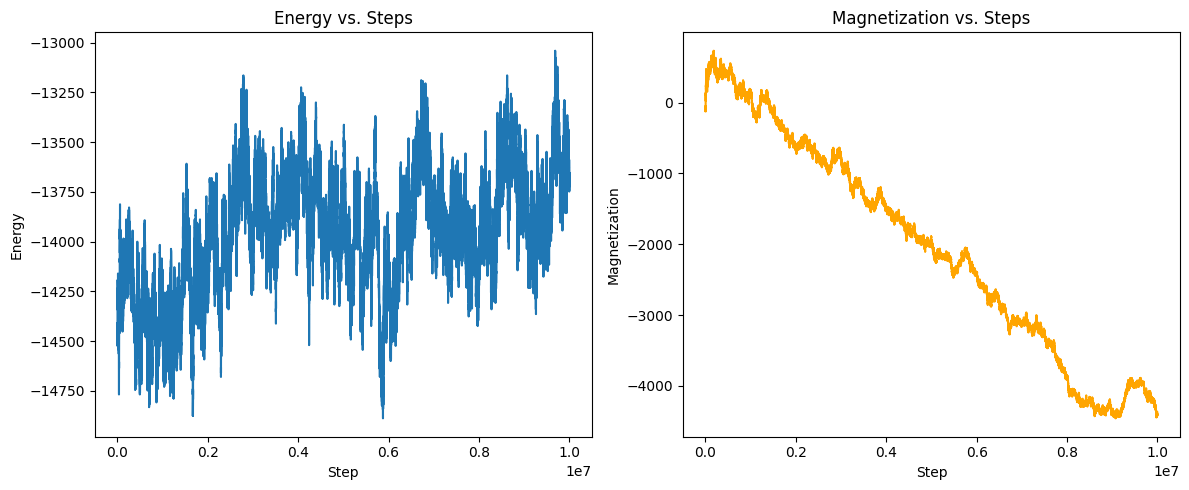

β sweep:  56%|█████▋    | 9/16 [07:09<05:22, 46.07s/it]

Loading checkpoint for β=0.4500
Acceptance rate: 0.1866


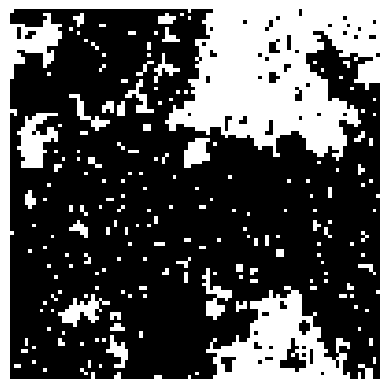

β sweep:  56%|█████▋    | 9/16 [07:24<05:45, 49.37s/it]


KeyboardInterrupt: 

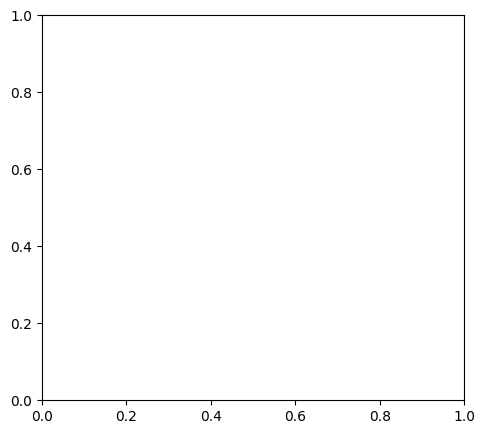

In [15]:
run2_dir = f"{base_dir}/second_states"
os.makedirs(run2_dir, exist_ok=True)

run2_checkpoint_dir = f"{run2_dir}/checkpoint_states"
os.makedirs(run2_checkpoint_dir, exist_ok=True)

run2_results_dir = f"{run2_dir}/results"
os.makedirs(run2_results_dir, exist_ok=True)

for beta in tqdm(beta_ls, desc="β sweep"):
    chk_file = f"{run1_checkpoint_dir}/state_beta_{beta:.4f}.npy"
    out_file = f"{run2_results_dir}/results_beta_{beta:.4f}.npz"

    # Try to load checkpoint state for this beta
    if os.path.exists(chk_file):
        print(f"Loading checkpoint for β={beta:.4f}")
        state = np.load(chk_file)
    else:
        print(f"No checkpoint for β={beta:.4f}, using previous state.")

    # Run continuation
    energies, mags, acc_rate, final_state = continue_metropolis(state, J, h, beta, n_steps)

    # Save output data
    np.savez_compressed(
        out_file,
        beta=beta,
        energies=energies,
        magnetizations=mags,
        acceptance_rate=acc_rate,
    )
    # Save last state as a checkpoint (for continuation)
    np.save(f"{run2_checkpoint_dir}/state_beta_{beta:.4f}.npy", final_state.astype(np.int8))

    print(f"Acceptance rate: {acc_rate:.4f}")
    plot_state(final_state)
    plot_energies_and_magnetizations(energies, magnetizations)

β sweep:   0%|          | 0/16 [00:00<?, ?it/s]

Loading checkpoint for β=0.1000
Acceptance rate: 0.8488


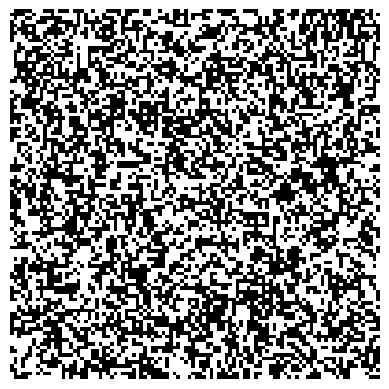

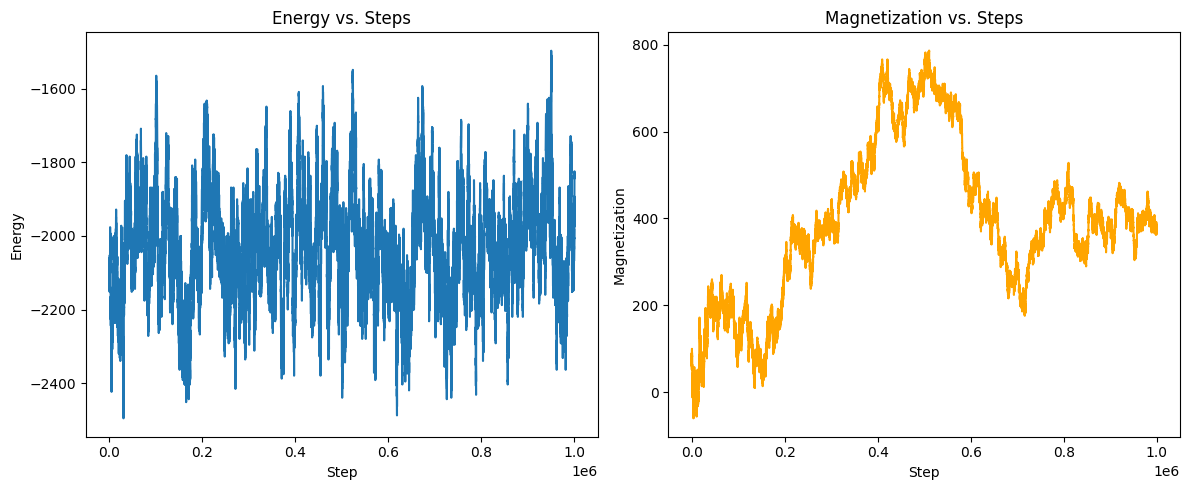

β sweep:   6%|▋         | 1/16 [00:02<00:30,  2.04s/it]

Loading checkpoint for β=0.2000
Acceptance rate: 0.6928


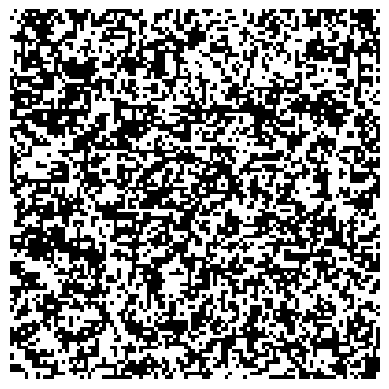

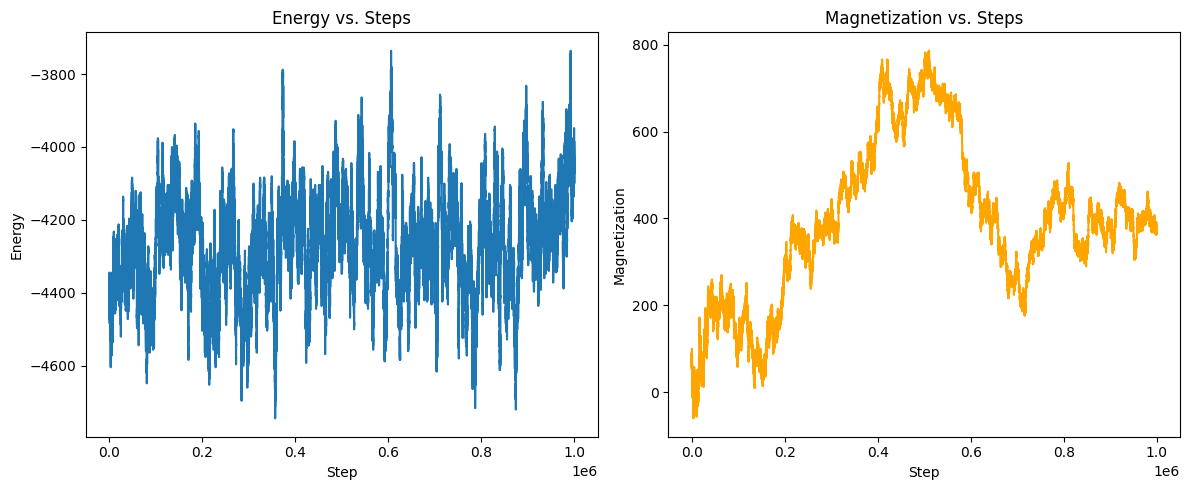

β sweep:  12%|█▎        | 2/16 [00:04<00:30,  2.17s/it]

Loading checkpoint for β=0.3000
Acceptance rate: 0.5194


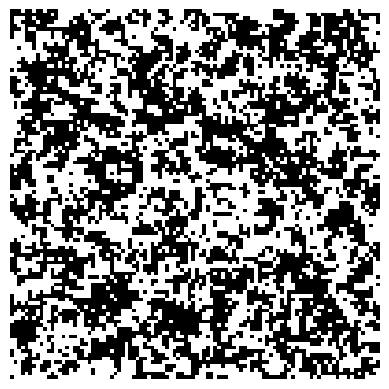

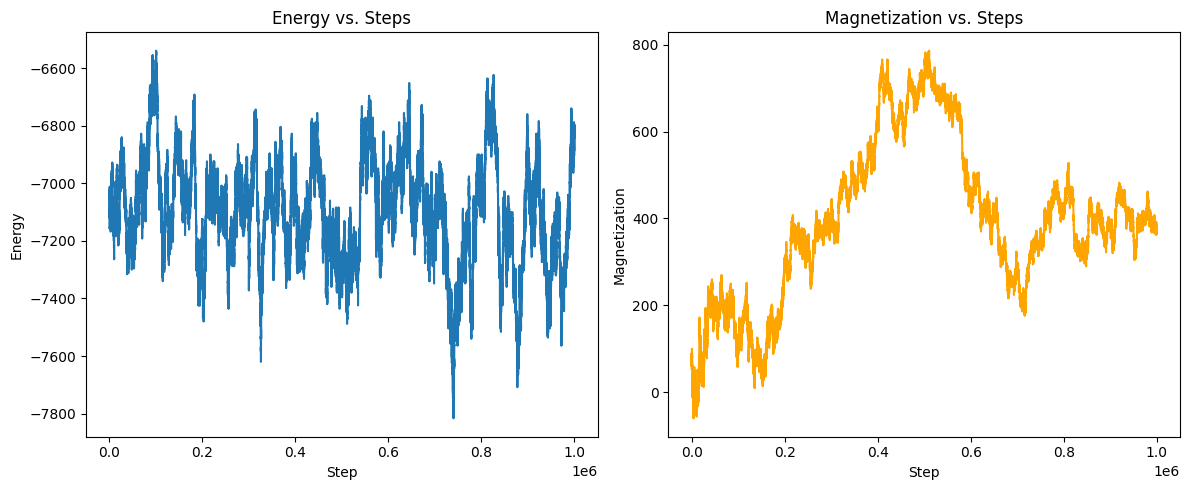

β sweep:  19%|█▉        | 3/16 [00:06<00:27,  2.15s/it]

Loading checkpoint for β=0.4000
Acceptance rate: 0.3257


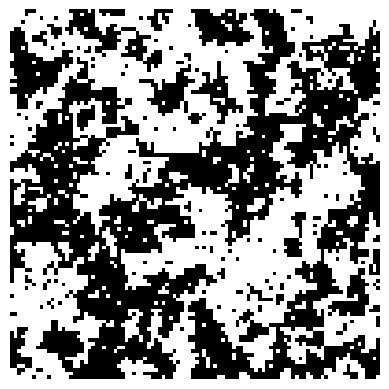

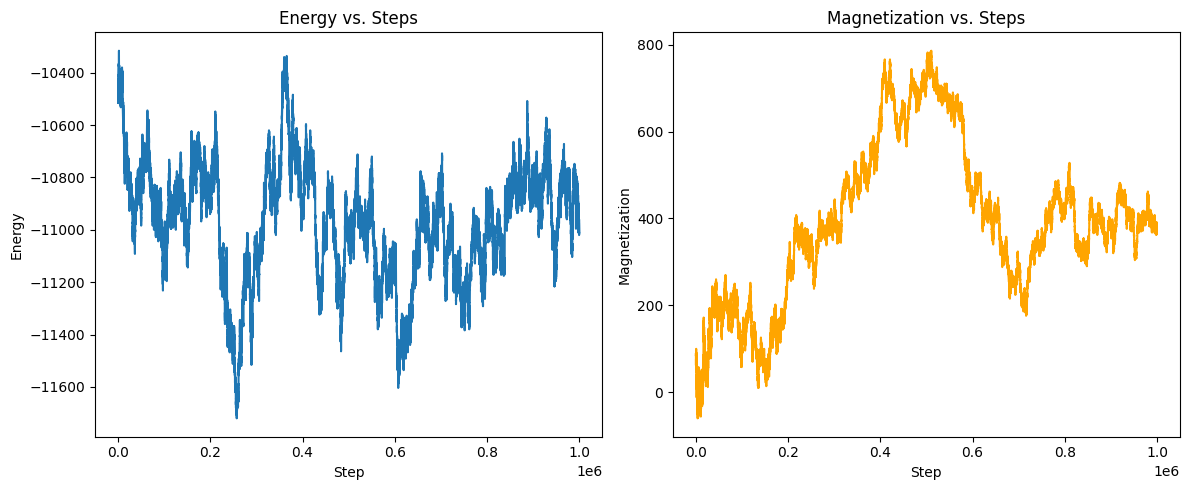

β sweep:  25%|██▌       | 4/16 [00:08<00:24,  2.05s/it]

Loading checkpoint for β=0.4100
Acceptance rate: 0.2993


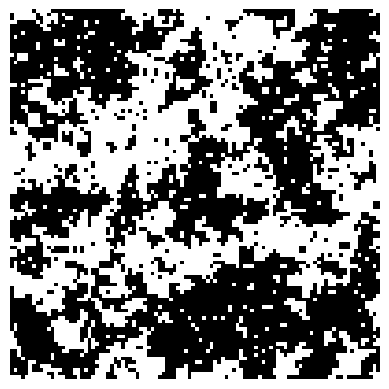

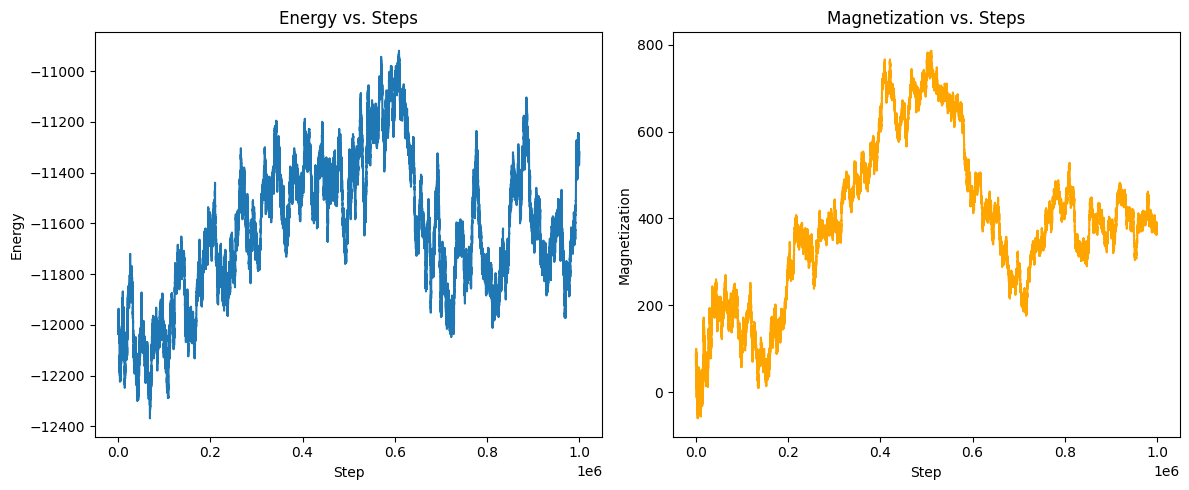

β sweep:  31%|███▏      | 5/16 [00:10<00:22,  2.02s/it]

Loading checkpoint for β=0.4200
Acceptance rate: 0.2687


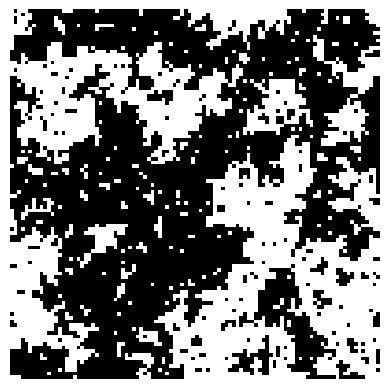

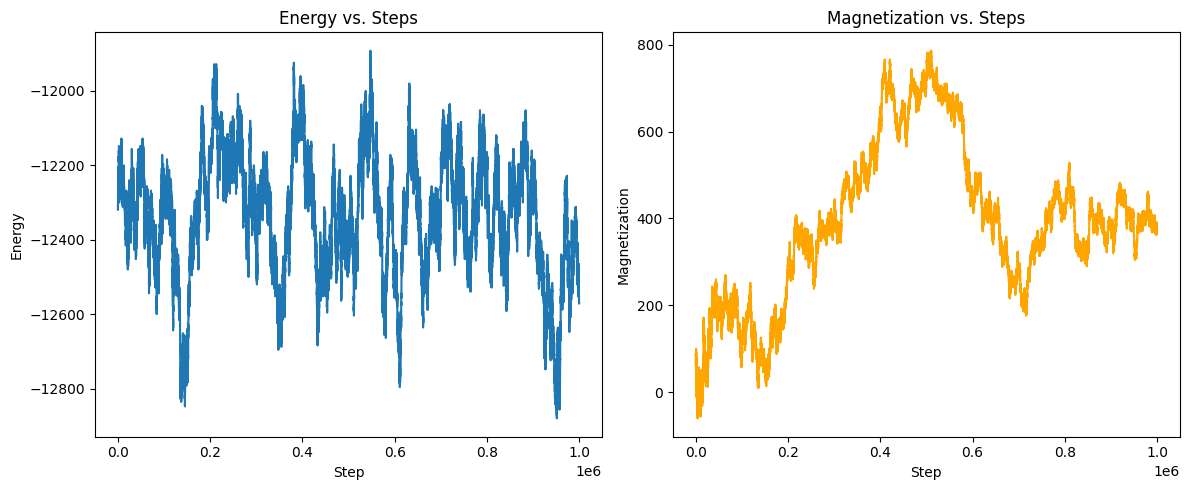

β sweep:  38%|███▊      | 6/16 [00:12<00:19,  1.97s/it]

Loading checkpoint for β=0.4300
Acceptance rate: 0.2513


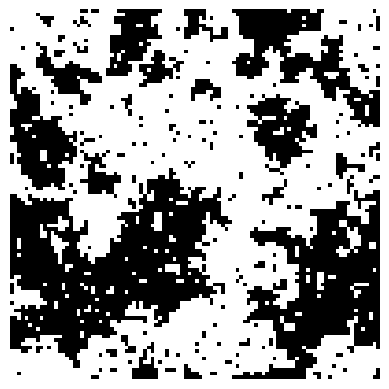

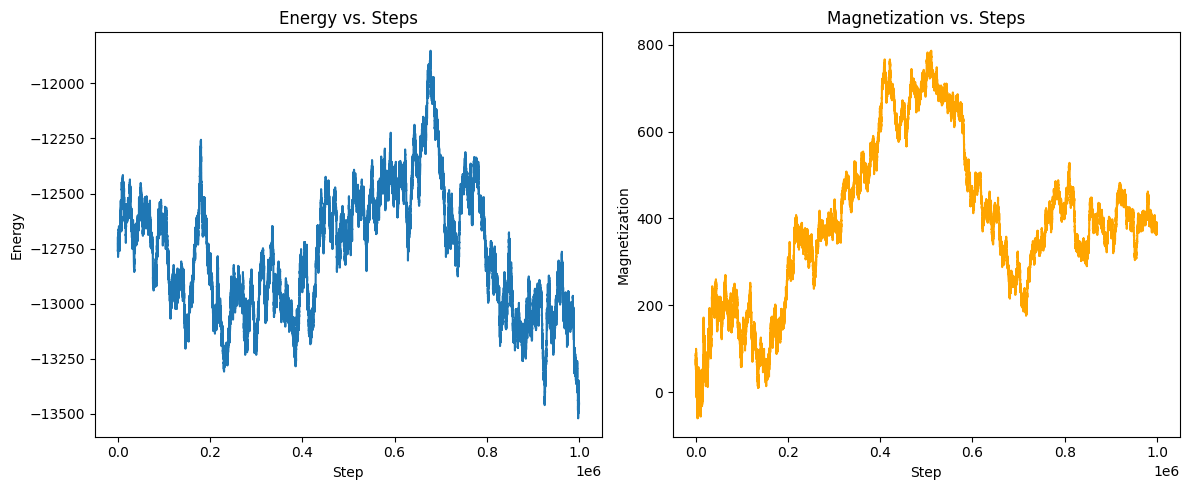

β sweep:  44%|████▍     | 7/16 [00:14<00:18,  2.00s/it]

Loading checkpoint for β=0.4400
Acceptance rate: 0.2106


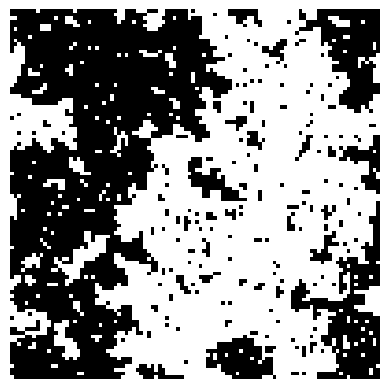

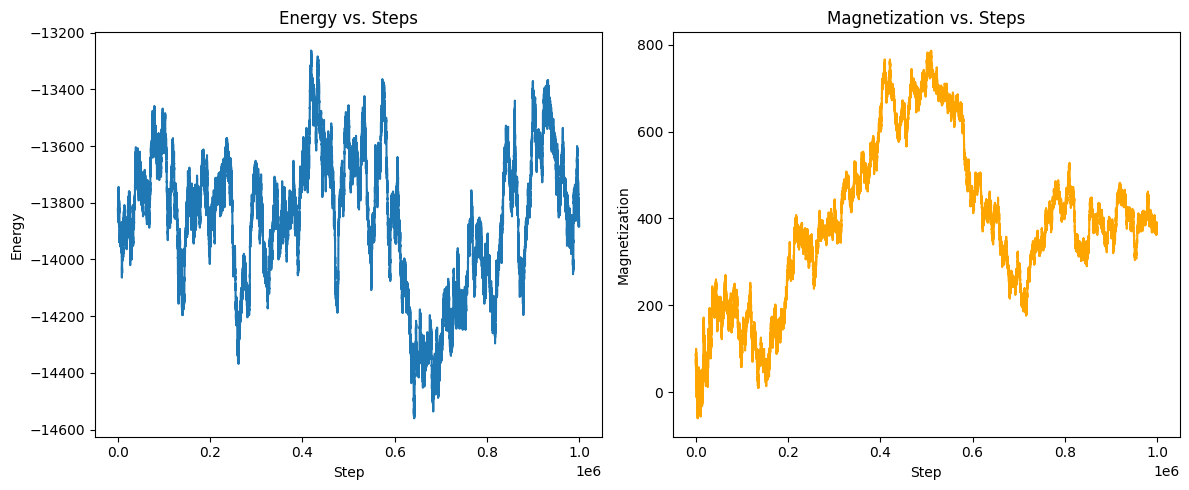

β sweep:  50%|█████     | 8/16 [00:17<00:18,  2.36s/it]

Loading checkpoint for β=0.4407
Acceptance rate: 0.2208


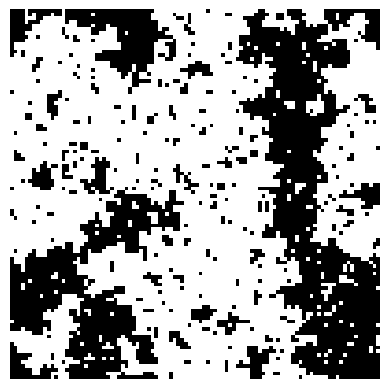

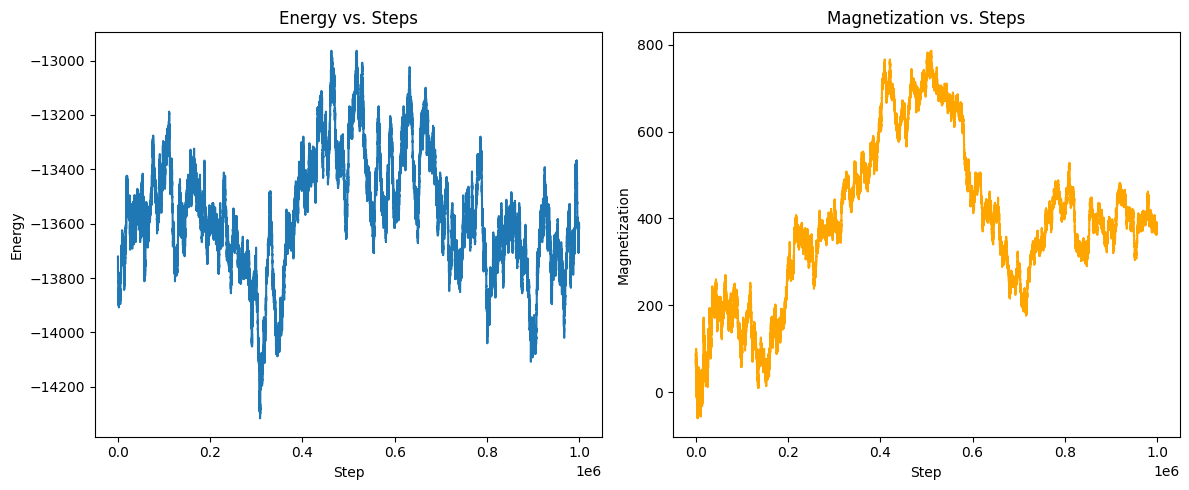

β sweep:  56%|█████▋    | 9/16 [00:19<00:16,  2.34s/it]

Loading checkpoint for β=0.4500
Acceptance rate: 0.2063


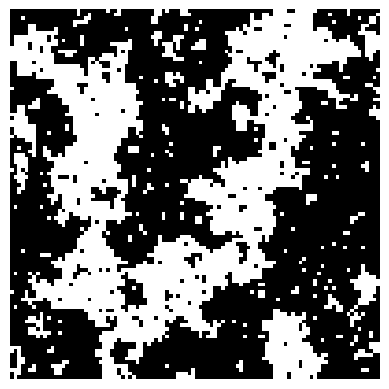

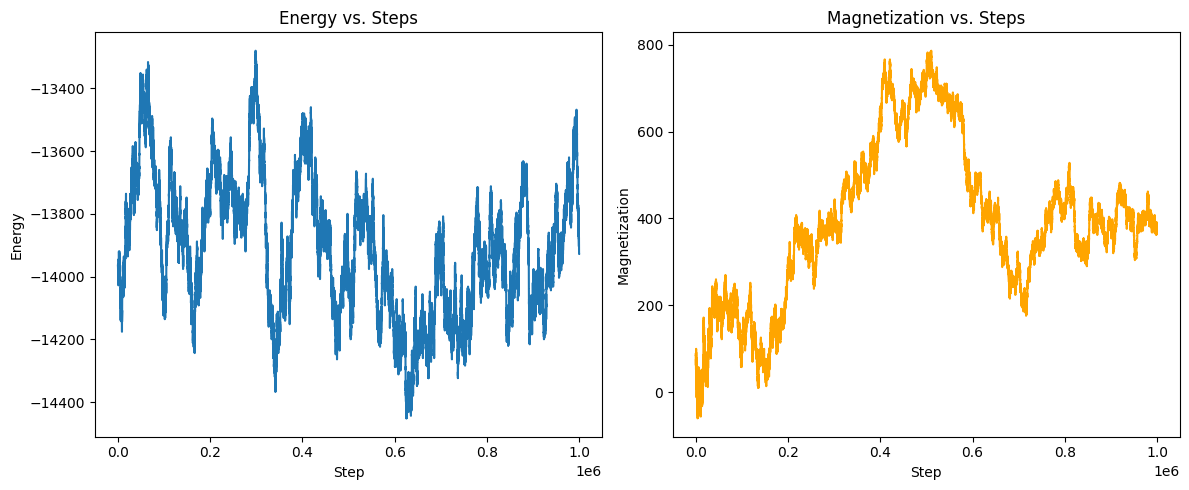

β sweep:  62%|██████▎   | 10/16 [00:21<00:12,  2.12s/it]

Loading checkpoint for β=0.4600
Acceptance rate: 0.1759


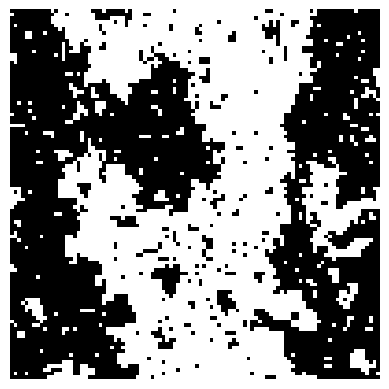

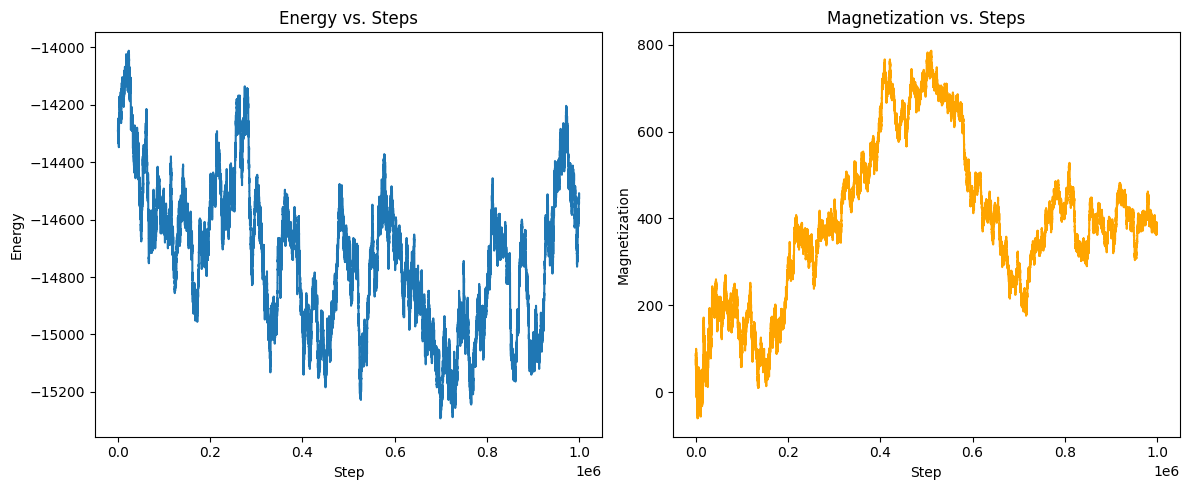

β sweep:  69%|██████▉   | 11/16 [00:22<00:09,  1.96s/it]

Loading checkpoint for β=0.4700
Acceptance rate: 0.1684


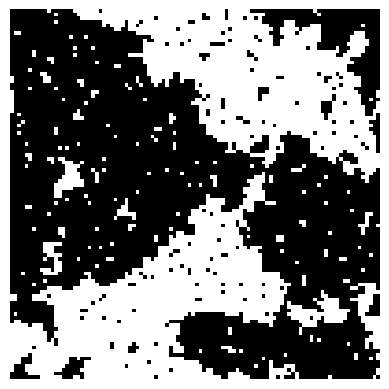

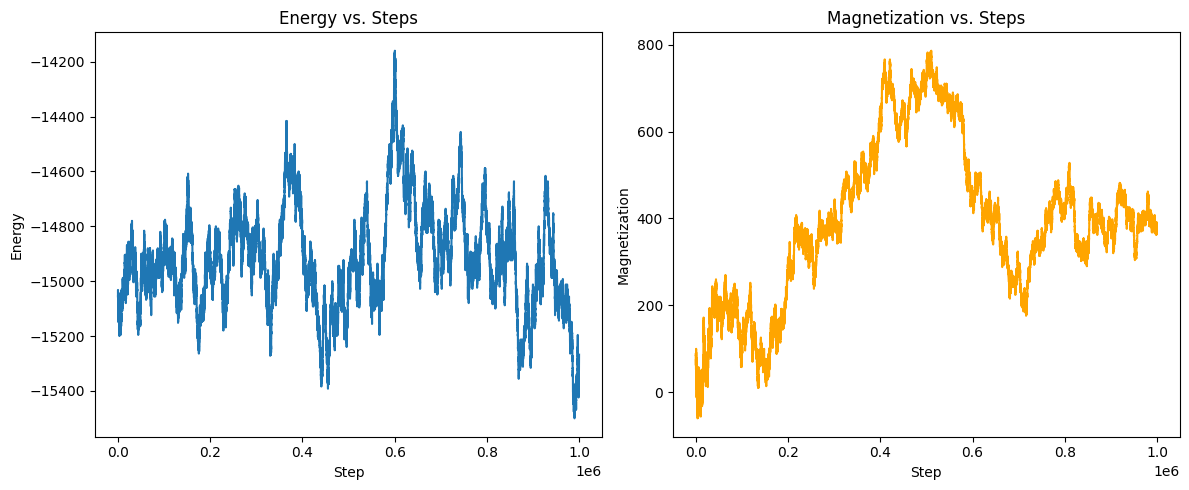

β sweep:  75%|███████▌  | 12/16 [00:25<00:08,  2.03s/it]

Loading checkpoint for β=0.4800
Acceptance rate: 0.1391


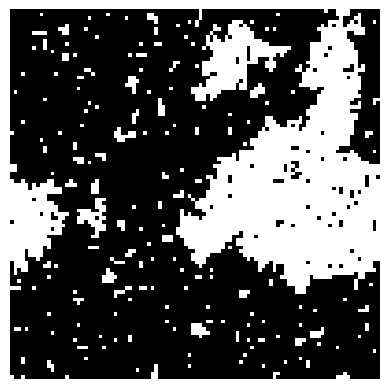

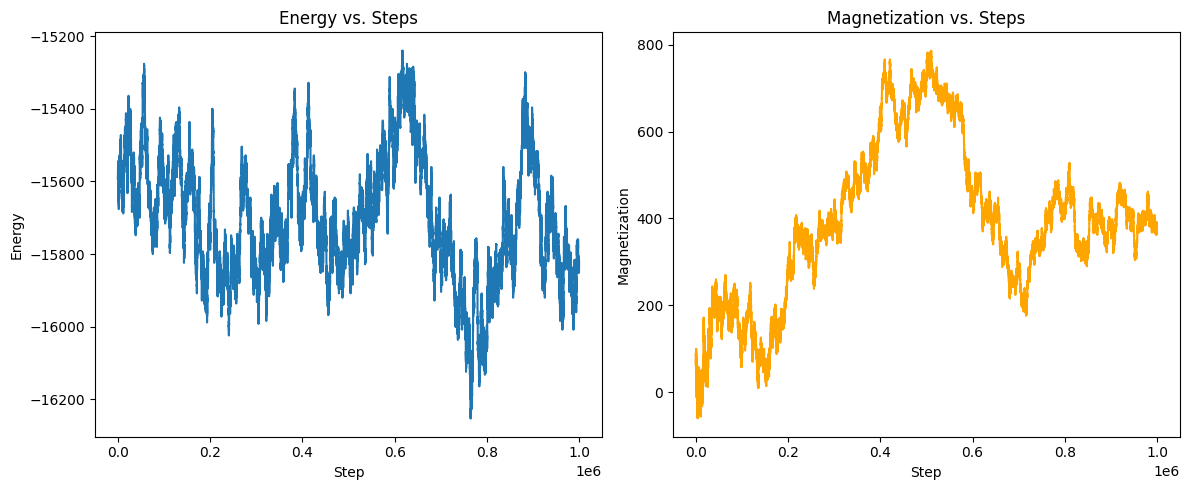

β sweep:  81%|████████▏ | 13/16 [00:26<00:05,  1.93s/it]

Loading checkpoint for β=0.4900
Acceptance rate: 0.1357


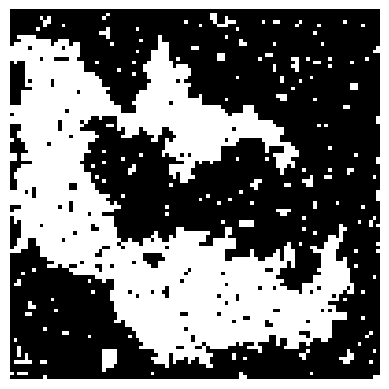

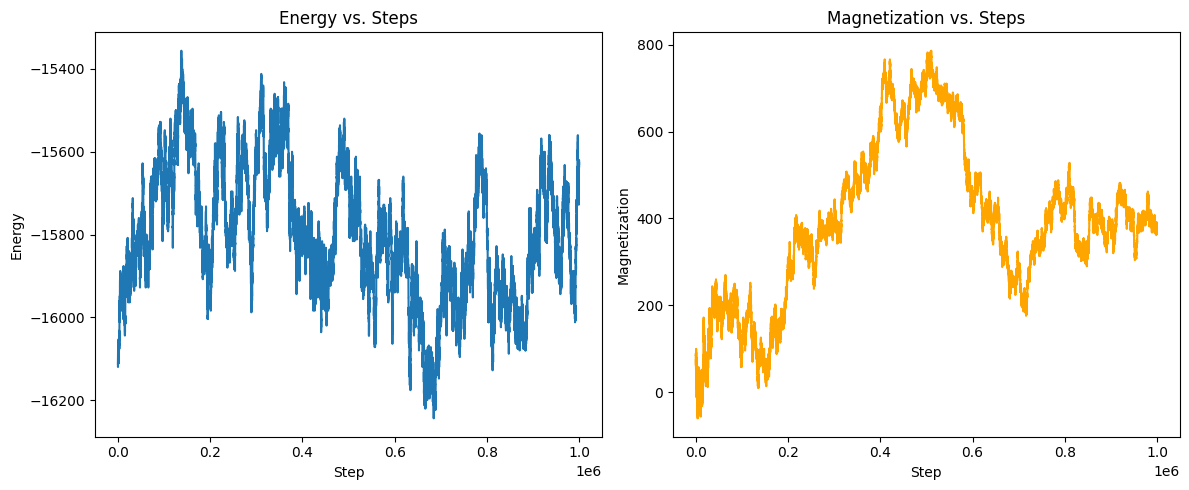

β sweep:  88%|████████▊ | 14/16 [00:28<00:03,  1.89s/it]

Loading checkpoint for β=0.5000
Acceptance rate: 0.1276


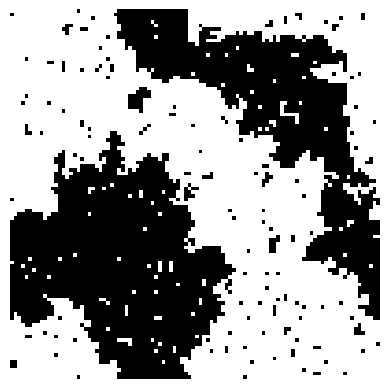

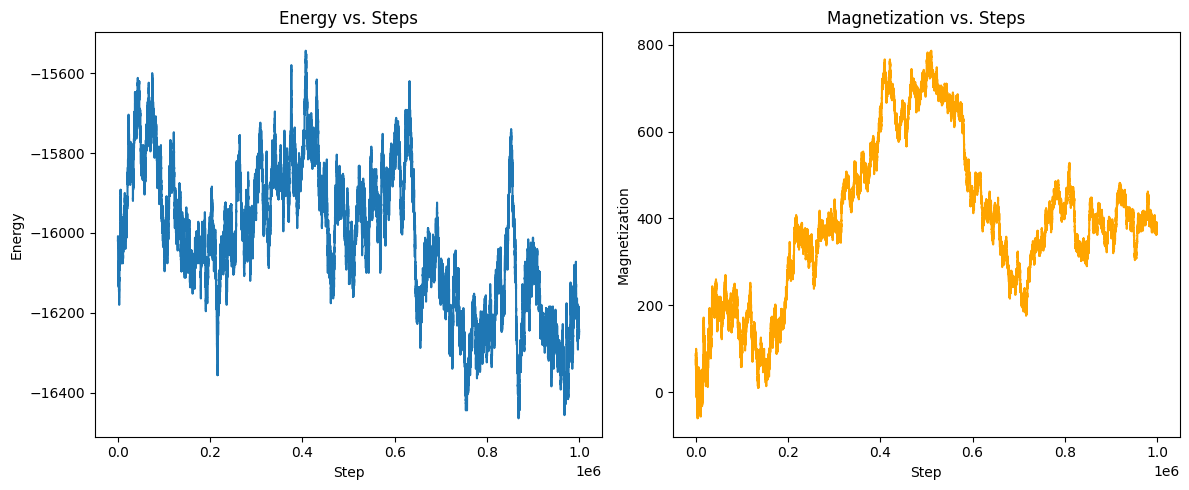

β sweep:  94%|█████████▍| 15/16 [00:30<00:01,  1.98s/it]

Loading checkpoint for β=0.6000
Acceptance rate: 0.0613


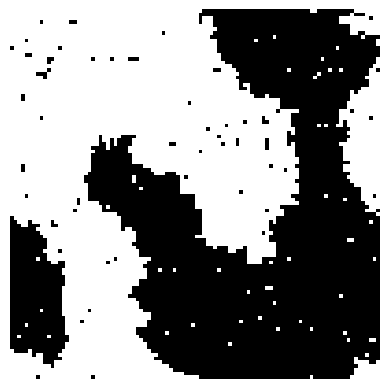

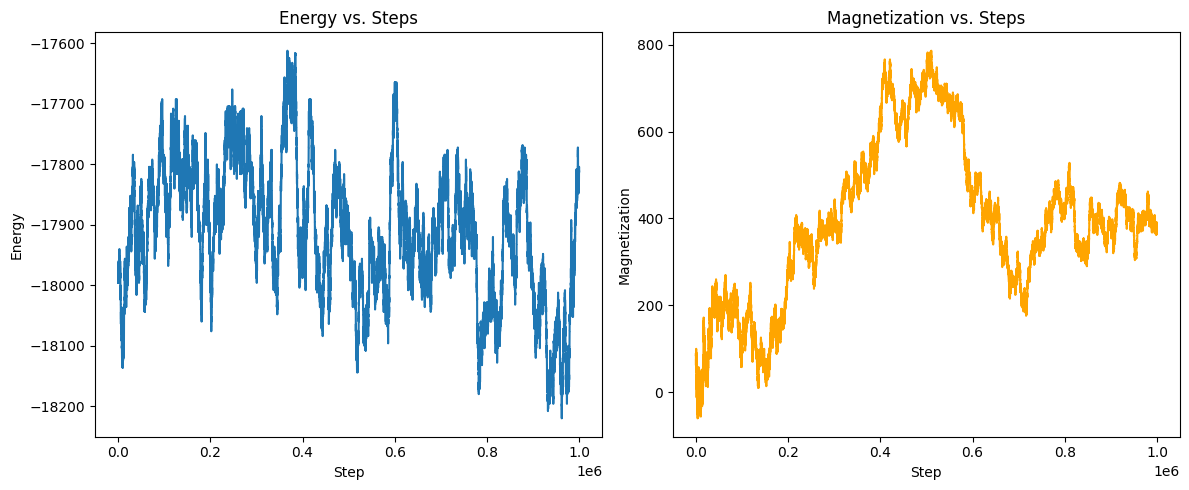

β sweep: 100%|██████████| 16/16 [00:32<00:00,  2.03s/it]


In [ ]:
run3_dir = f"{base_dir}/third_states"
os.makedirs(run3_dir, exist_ok=True)

run3_checkpoint_dir = f"{run3_dir}/checkpoint_states"
os.makedirs(run3_checkpoint_dir, exist_ok=True)

run3_results_dir = f"{run3_dir}/results"
os.makedirs(run3_results_dir, exist_ok=True)

for beta in tqdm(beta_ls, desc="β sweep"):
    chk_file = f"{run2_checkpoint_dir}/state_beta_{beta:.4f}.npy"
    out_file = f"{run3_results_dir}/results_beta_{beta:.4f}.npz"

    # Try to load checkpoint state for this beta
    if os.path.exists(chk_file):
        print(f"Loading checkpoint for β={beta:.4f}")
        state = np.load(chk_file)
    else:
        print(f"No checkpoint for β={beta:.4f}, using previous state.")

    # Run continuation
    energies, mags, acc_rate, final_state = continue_metropolis(state, J, h, beta, n_steps)

    # Save output data
    np.savez_compressed(
        out_file,
        beta=beta,
        energies=energies,
        magnetizations=mags,
        acceptance_rate=acc_rate,
    )
    # Save last state as a checkpoint (for continuation)
    np.save(f"{run3_checkpoint_dir}/state_beta_{beta:.4f}.npy", final_state.astype(np.int8))

    print(f"Acceptance rate: {acc_rate:.4f}")
    plot_state(final_state)
    plot_energies_and_magnetizations(energies, magnetizations)

β sweep:   0%|          | 0/16 [00:00<?, ?it/s]

Loading checkpoint for β=0.1000
Acceptance rate: 0.8486


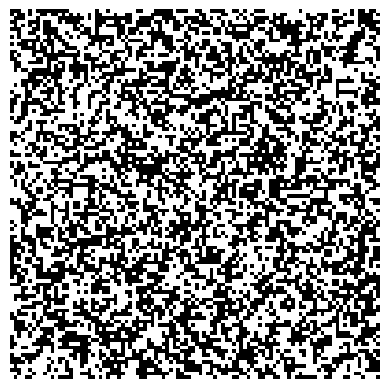

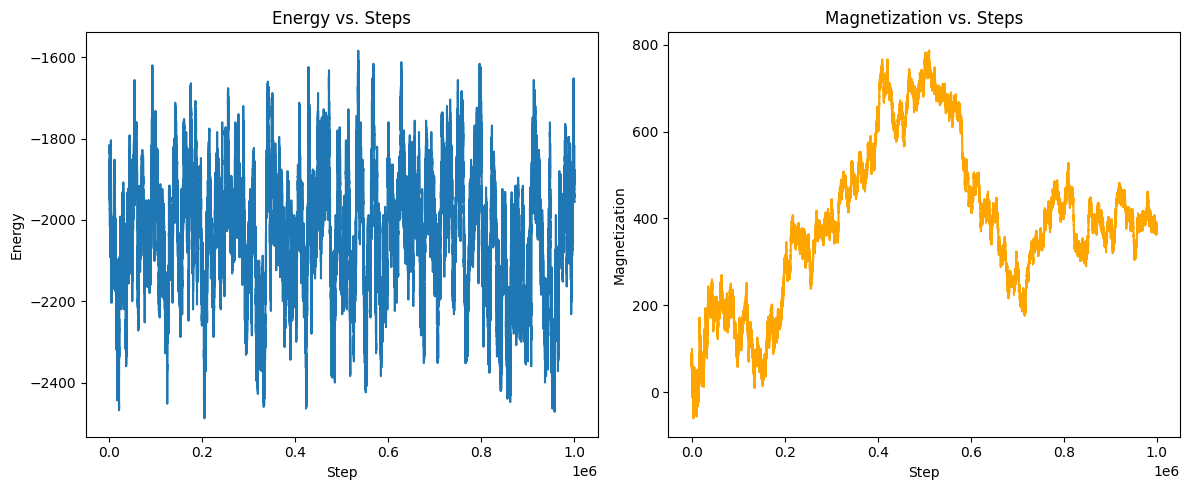

β sweep:   6%|▋         | 1/16 [00:01<00:24,  1.64s/it]

Loading checkpoint for β=0.2000
Acceptance rate: 0.6934


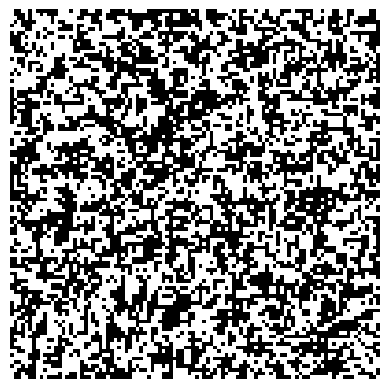

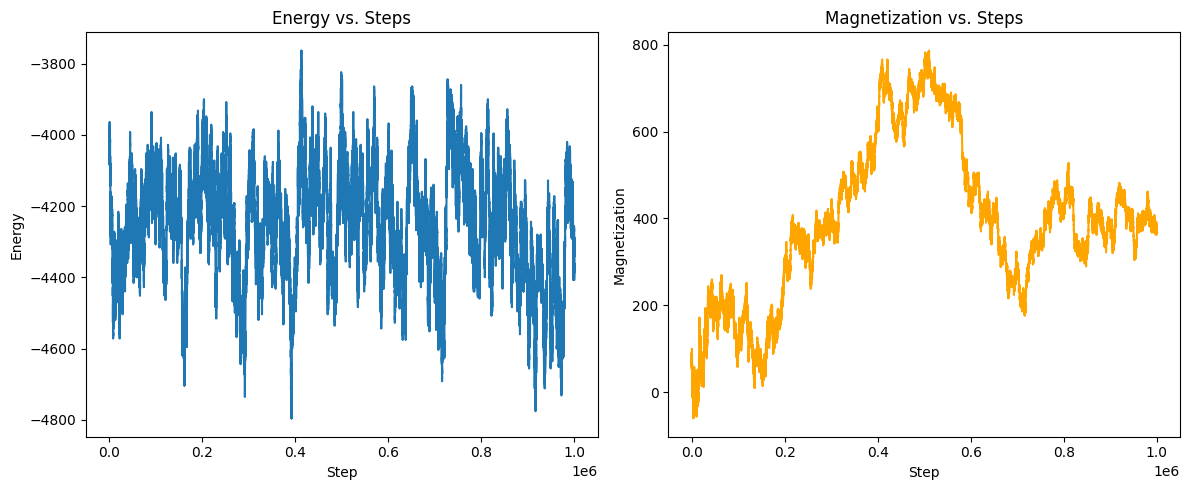

β sweep:  12%|█▎        | 2/16 [00:03<00:28,  2.06s/it]

Loading checkpoint for β=0.3000
Acceptance rate: 0.5219


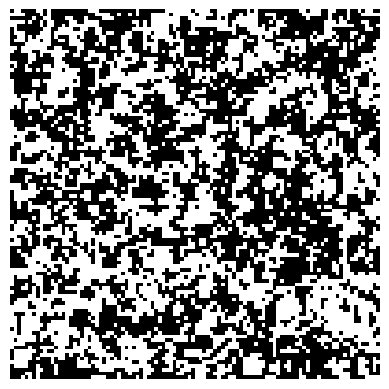

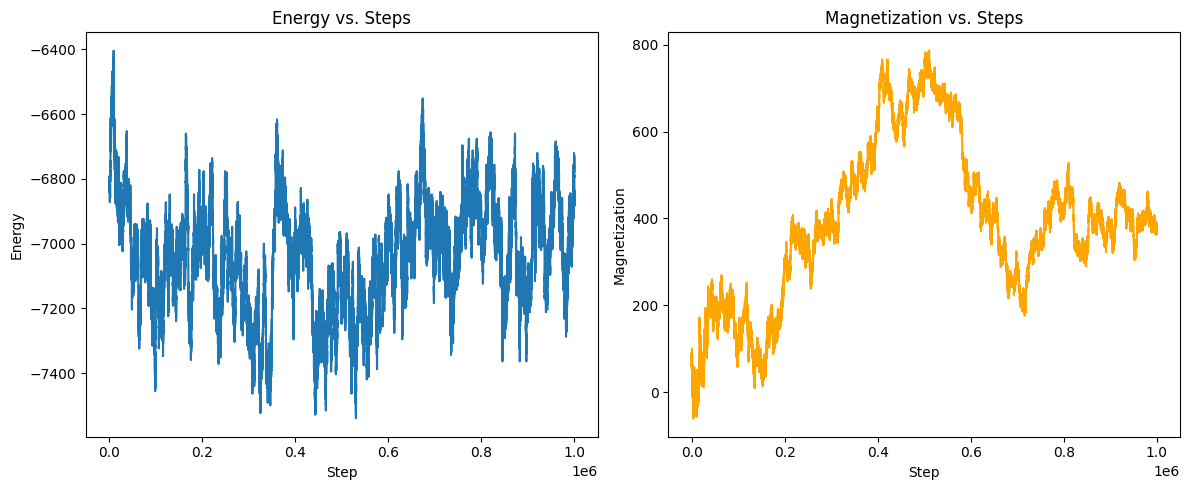

β sweep:  19%|█▉        | 3/16 [00:05<00:26,  2.00s/it]

Loading checkpoint for β=0.4000
Acceptance rate: 0.3286


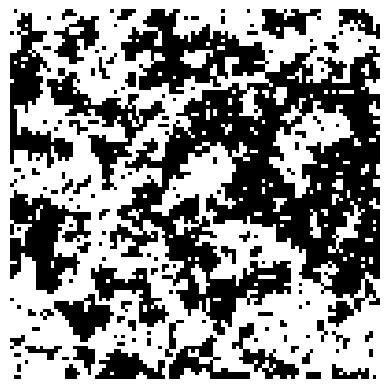

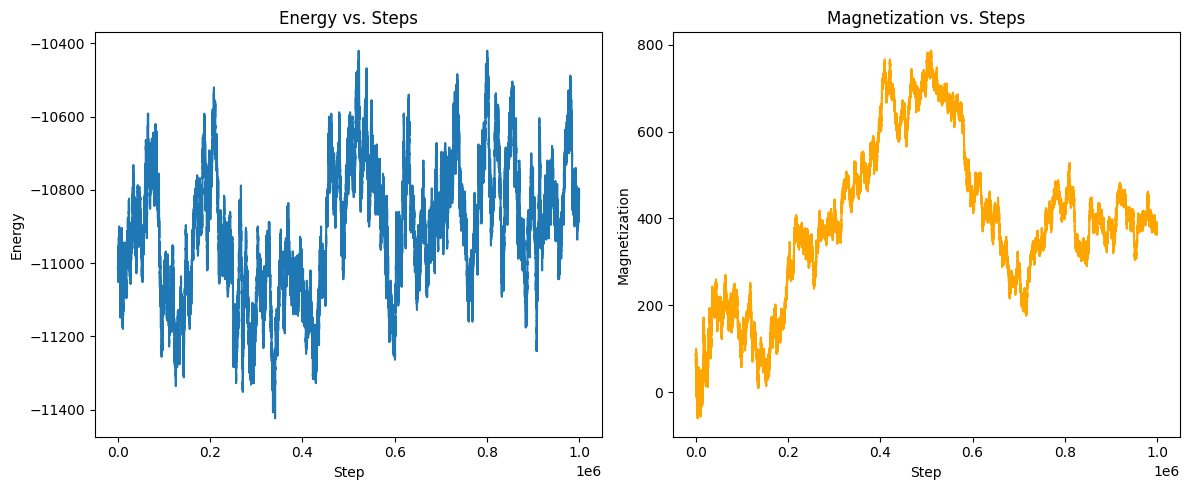

β sweep:  25%|██▌       | 4/16 [00:07<00:22,  1.90s/it]

Loading checkpoint for β=0.4100
Acceptance rate: 0.2997


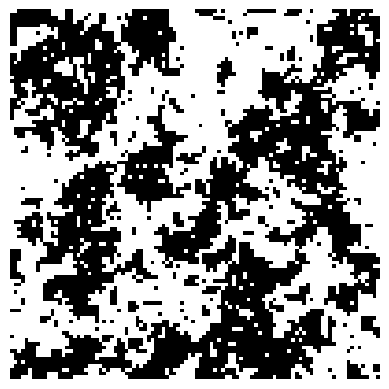

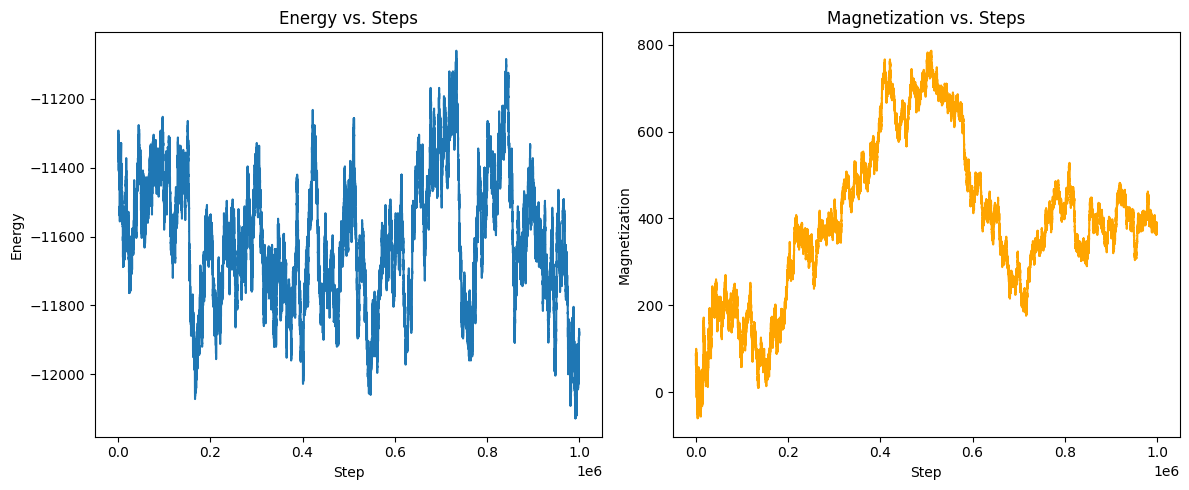

β sweep:  31%|███▏      | 5/16 [00:09<00:20,  1.82s/it]

Loading checkpoint for β=0.4200
Acceptance rate: 0.2689


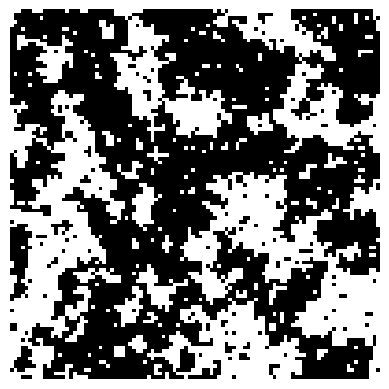

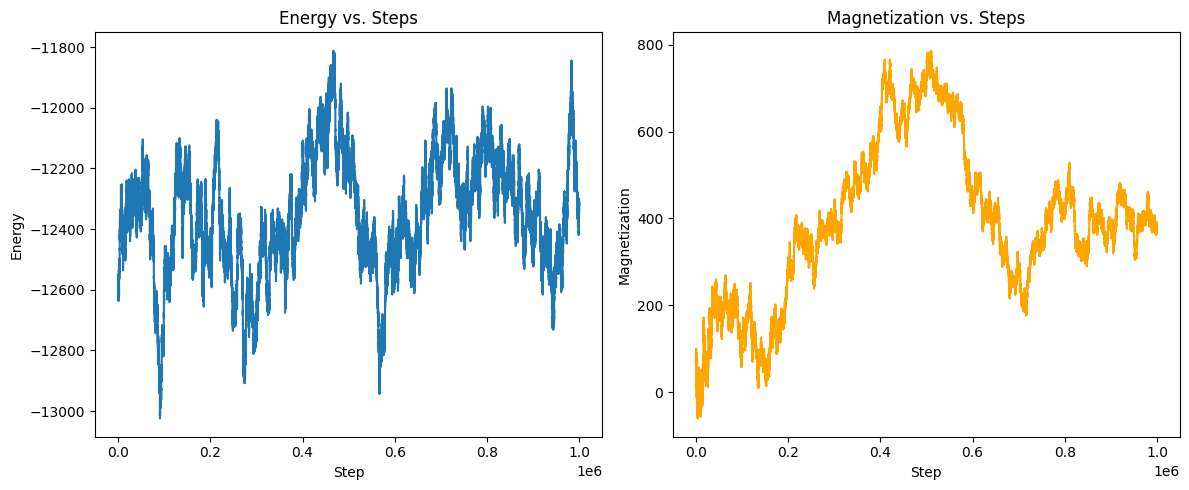

β sweep:  38%|███▊      | 6/16 [00:11<00:17,  1.78s/it]

Loading checkpoint for β=0.4300
Acceptance rate: 0.2476


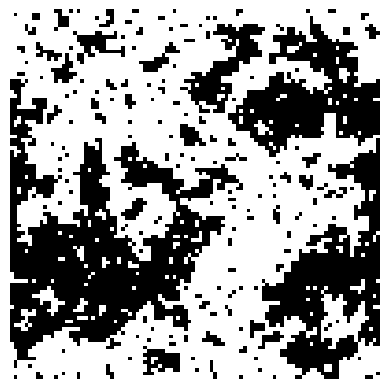

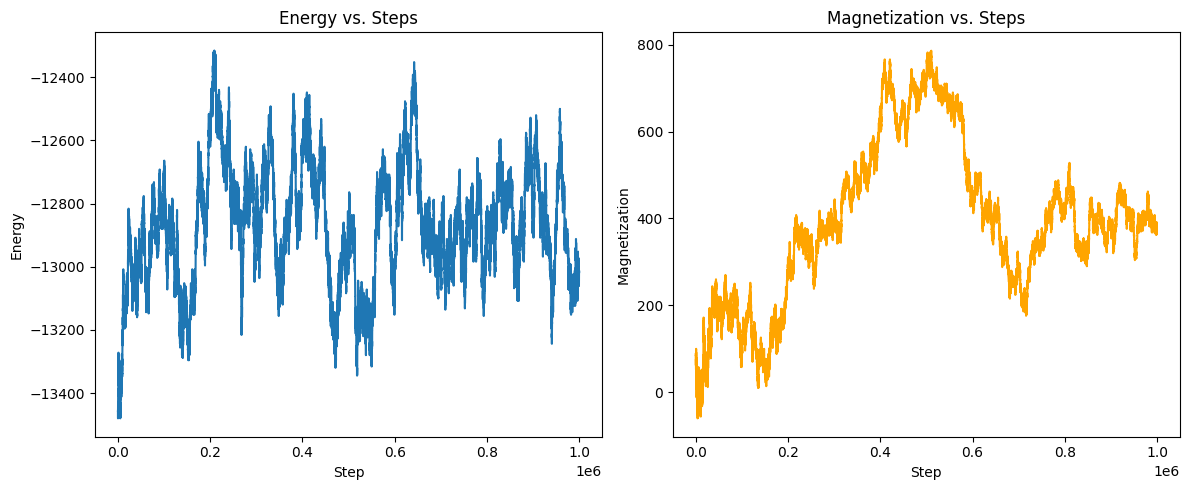

β sweep:  44%|████▍     | 7/16 [00:13<00:18,  2.07s/it]

Loading checkpoint for β=0.4400
Acceptance rate: 0.2139


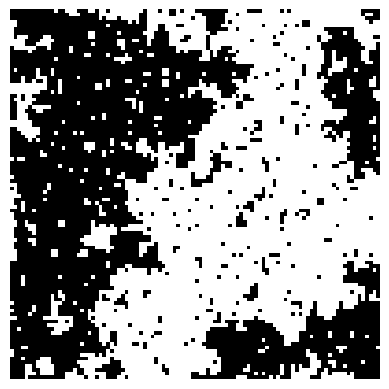

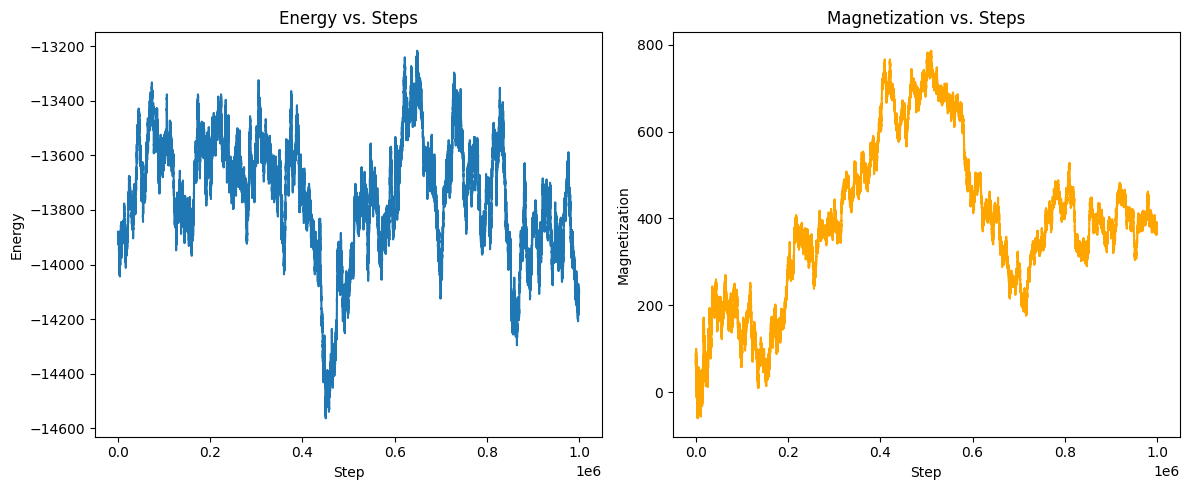

β sweep:  50%|█████     | 8/16 [00:16<00:17,  2.24s/it]

Loading checkpoint for β=0.4407
Acceptance rate: 0.2256


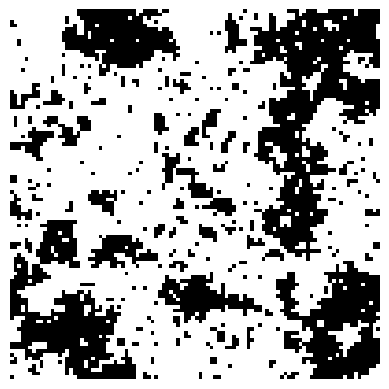

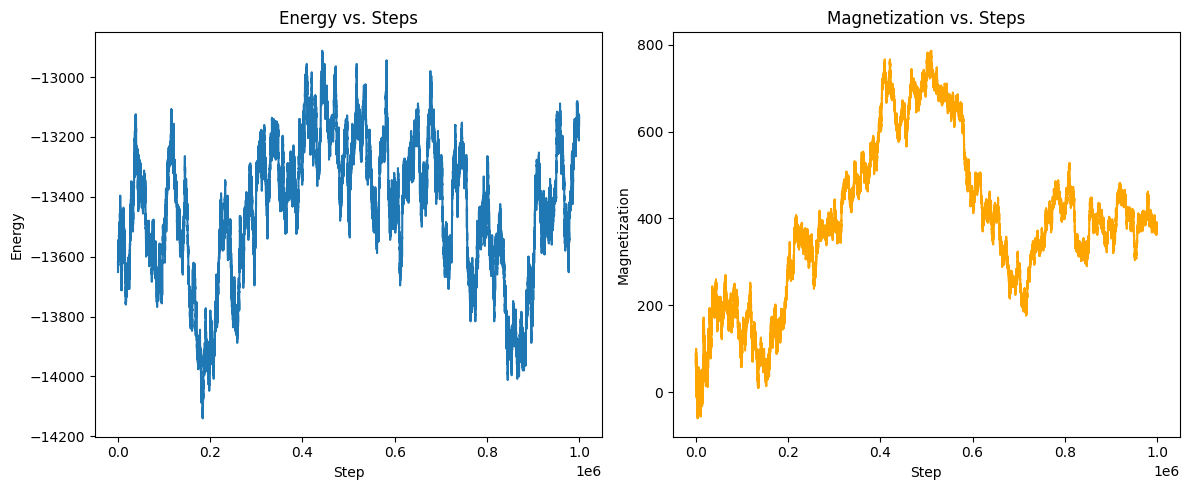

β sweep:  56%|█████▋    | 9/16 [00:19<00:17,  2.46s/it]

Loading checkpoint for β=0.4500
Acceptance rate: 0.1996


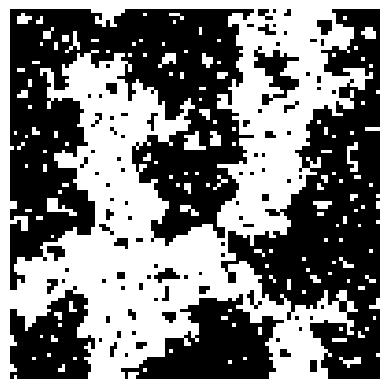

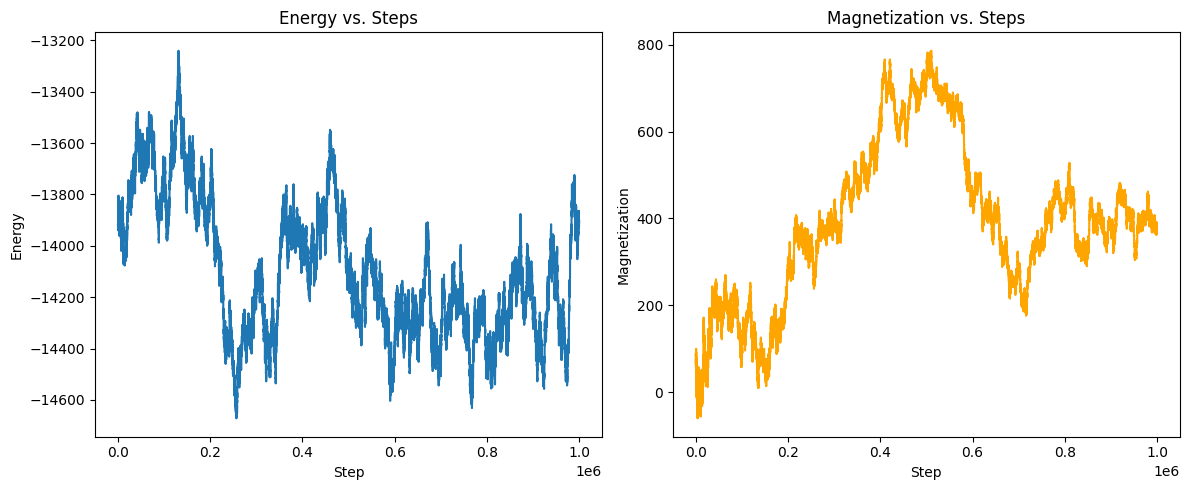

β sweep:  62%|██████▎   | 10/16 [00:22<00:15,  2.56s/it]

Loading checkpoint for β=0.4600
Acceptance rate: 0.1764


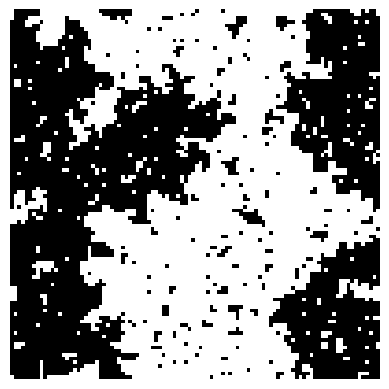

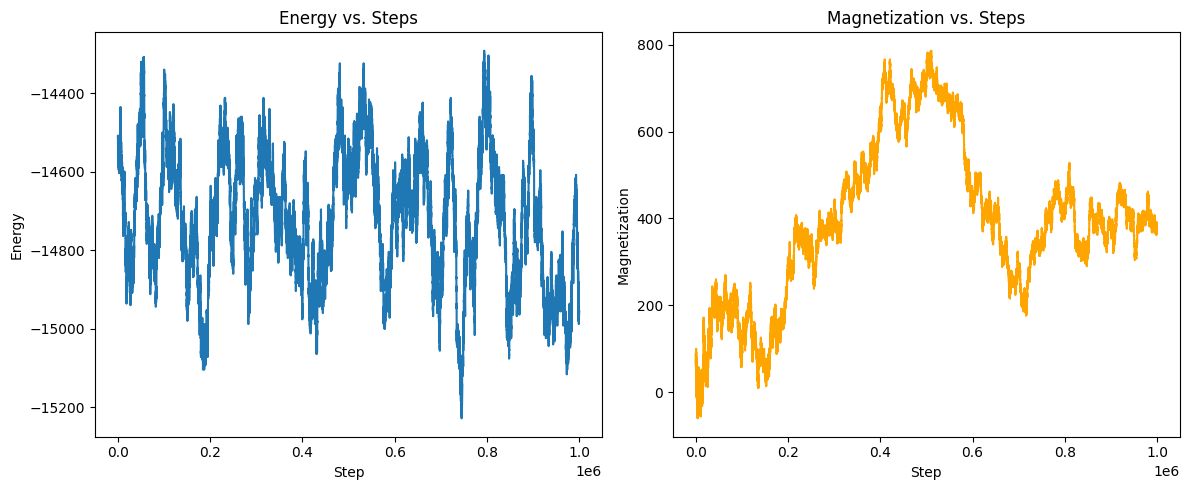

β sweep:  69%|██████▉   | 11/16 [00:24<00:13,  2.63s/it]

Loading checkpoint for β=0.4700


β sweep:  69%|██████▉   | 11/16 [00:25<00:11,  2.36s/it]


KeyboardInterrupt: 

In [ ]:
run4_dir = f"{base_dir}/fourth_states"
os.makedirs(run4_dir, exist_ok=True)

run4_checkpoint_dir = f"{run4_dir}/checkpoint_states"
os.makedirs(run4_checkpoint_dir, exist_ok=True)

run4_results_dir = f"{run4_dir}/results"
os.makedirs(run4_results_dir, exist_ok=True)

for beta in tqdm(beta_ls, desc="β sweep"):
    chk_file = f"{run3_checkpoint_dir}/state_beta_{beta:.4f}.npy"
    out_file = f"{run4_results_dir}/results_beta_{beta:.4f}.npz"

    # Try to load checkpoint state for this beta
    if os.path.exists(chk_file):
        print(f"Loading checkpoint for β={beta:.4f}")
        state = np.load(chk_file)
    else:
        print(f"No checkpoint for β={beta:.4f}, using previous state.")

    # Run continuation
    energies, mags, acc_rate, final_state = continue_metropolis(state, J, h, beta, n_steps)

    # Save output data
    np.savez_compressed(
        out_file,
        beta=beta,
        energies=energies,
        magnetizations=mags,
        acceptance_rate=acc_rate,
    )
    # Save last state as a checkpoint (for continuation)
    np.save(f"{run4_checkpoint_dir}/state_beta_{beta:.4f}.npy", final_state.astype(np.int8))

    print(f"Acceptance rate: {acc_rate:.4f}")
    plot_state(final_state)
    plot_energies_and_magnetizations(energies, magnetizations)